# Импорт библиотек и настройка среды

In [2475]:
import pandas as pd
from statsmodels.stats.proportion import proportion_confint
import numpy as np
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns
import dataframe_image as dfi
from pathlib import Path

In [2476]:
pd.set_option("display.max_columns", 100)
pd.set_option('display.max_colwidth', None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Удобства для навигации

In [2477]:
navigation = dict()

# Вспомогательные функции и схемы

## Функция для создания сегментов

In [2478]:
def make_segments_continuos_feature(
    data: pd.DataFrame,
    feature: str,
    special_values: list[float] = []
) -> list[float]:
    mask = data[feature].isin(special_values)
    feature = data.loc[~mask, feature]

    super_segments = np.unique(
        np.quantile(
            a=feature,
            q=[0.0, 0.005, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99, 0.995, 1.0]
        )
    ).tolist()

    segments = []
    for i in range(len(super_segments)-1):
        left = super_segments[i]
        right = super_segments[i+1]

        mask = (left <= feature) & (feature <= right)

        segments.extend(
            np.quantile(
                a=feature[mask],
                q=np.linspace(0, 1, 4)
            ).tolist()
        )

    segments = list(
        map(
            lambda x: round(x, 2),
            segments
        )
    )
    segments.extend([min(feature), max(feature)])
    segments = sorted(
        np.unique(segments).tolist()
    )
    
    return segments

In [2479]:
def make_values(
    data: pd.DataFrame,
    feature: str,
    special_values: list[float] = [],
    segments: list[float] = []
) -> list[float]:
    mask = data[feature].isin(special_values + segments)
    feature = data.loc[~mask, feature]

    values = sorted(feature.unique().tolist())
    
    return values

## Функция для создания labels по сегментам

In [2480]:
def make_labels(
    segments: list[float]
) -> list[str]:
    labels = []
    
    for i in range(len(segments) - 1):
        left = segments[i]
        right = segments[i + 1]

        if i == 0:
            labels.append(f"[{left}, {right}]")
        else:
            labels.append(f"({left}, {right}]")

    return labels

## Функция для создания столбца маркеров сегментов

In [2481]:
def make_segment_col_continuos_feature(
    data: pd.DataFrame,
    feature: str,
    segment_col_name: str,
    segments: list[float],
    special_values: list[float] = []
) -> list[str]:
    labels = make_labels(segments)

    data[segment_col_name] = pd.cut(
        x=data[feature],
        bins=segments,
        labels=labels,
        right=True,
        include_lowest=True
    )


    special_labels = []
    if special_values:
        for special_value in special_values:
            if pd.isna(special_value):
                label = "NaN"
            else:
                label = str(special_value)

            special_labels.append(label)

        new_categories = [
            label
            for label in special_labels
            if label not in data[segment_col_name].cat.categories
        ]

        data[segment_col_name] = (
            data[segment_col_name]
            .cat.add_categories(new_categories)
        )

        for special_value in special_values:
            if pd.isna(special_value):
                mask = data[feature].isna()
                label = "NaN"
            else:
                mask = data[feature].eq(special_value)
                label = str(special_value)

            data.loc[mask, segment_col_name] = label
    

    return labels + special_labels

In [2482]:
def make_segment_col_count_or_cat_feature(
    data: pd.DataFrame,
    feature: str,
    segment_col_name: str,
    values: list[float],
    segments: list[float] = [],
    special_values: list[float] = []
) -> list[str]:
    values_ = values
    if segments:
        values_ = [value for value in values if value not in set(range(segments[0], segments[-1]+1))]
    
    values_labels = list(map(str, values_))
    for value, value_label in zip(values_, values_labels):
        mask = data[feature].eq(value)
        data.loc[mask, segment_col_name] = value_label

    data[segment_col_name] = data[segment_col_name].astype("category")

    segments_labels = []
    if segments:
        segments_labels = make_labels(segments)

        new_categories = [
            label
            for label in segments_labels
        ]
        data[segment_col_name] = (
            data[segment_col_name]
            .cat.add_categories(new_categories)
        )

        mask = data[feature].isin(values_)
        data.loc[~mask, segment_col_name] = pd.cut(
            x=data.loc[~mask, feature],
            bins=segments,
            labels=segments_labels,
            right=True,
            include_lowest=True
        ).astype(object)

    special_values_labels = []
    if special_values:
        special_values_labels = [
            "Nan" if pd.isna(special_value) else str(special_value)
            for special_value in special_values
        ]

        new_categories = [
            label
            for label in special_values_labels
        ]

        data[segment_col_name] = (
            data[segment_col_name]
            .cat.add_categories(new_categories)
        )        

        for special_value in special_values:
            if pd.isna(special_value):
                mask = data[feature].isna()
                label = "Nan"
            else:
                mask = data[feature].eq(special_value)
                label = str(special_value)

            data.loc[mask, segment_col_name] = label
    

    return values_labels + segments_labels + special_values_labels

## Функция для соствления аналитического отчёта по признаку

In [2483]:
COLUMNS_SEGMENT_REPORT = [
    "segment",
    "clients",
    "dataset_share",
    "dataset_bad_rate",
    "bad_count",
    "bad_share",
    "bad_rate",
    "ci_low",
    "ci_high",
    "delta_bad_rate_pp",
    "lift"
]

In [2484]:
def make_segment_report_continuos_feature(
    data: pd.DataFrame,
    feature: str,
    segments: list[float],
    special_values: list[float] = [],
    target_feature: str = "target",
    out_path: str = ""
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Возвращает датасет с столбцом меток сегментов и таблицу отчёта сегментного анализа.

    Args:
        data: датасет.
        feature: наименование признака, сегментация которого будет оцениваться.
        segments: список границ сегментов, на который будет разбиваться признак.
        special_values: специальные значения, под которые нужно выделить сегменты.
        target_feature: наименования целевой переменной.
        out_path: путь, по которому нужно сохранить таблицу, если он отсутствует, то сохранения не происходит.

    Returns:
        Возвращает датасет с столбцом меток сегментов и таблицу отчёта сегментного анализа.
    """
    df = data.copy(deep=True)

    segment_col_name = f"{feature}_segments"

    df_size = df.shape[0] * 1.0
    df_bad_count = df[target_feature].sum()
    df_bad_rate = df[target_feature].mean()    

    segment_report = pd.DataFrame(columns=COLUMNS_SEGMENT_REPORT)

    labels = make_segment_col_continuos_feature(
        data=df,
        feature=feature,
        segment_col_name=segment_col_name,
        segments=segments,
        special_values=special_values
    )

    for label in labels:
        segment = df.loc[
            df[segment_col_name] == label
        ]

        clients = segment.shape[0]
        dataset_share = clients / df_size
        bad_count = segment[target_feature].sum()
        bad_rate = segment[target_feature].mean()
        ci_low, ci_high = proportion_confint(
            count=bad_count,
            nobs=clients,
            alpha=0.05,
            method="wilson"
        )
        delta_bad_rate_pp = round((bad_rate - df_bad_rate) * 100, 4)
        lift = round(bad_rate / df_bad_rate, 4)
        bad_share = round(bad_count / df_bad_count, 4)

        segment_report.loc[ segment_report.shape[0] ] = [
            label,
            clients,
            dataset_share,
            df_bad_rate,
            bad_count,
            bad_share,
            bad_rate,
            ci_low,
            ci_high,
            delta_bad_rate_pp,
            lift
        ]

    if out_path:
        out_path = Path(out_path)
        out_path.parent.mkdir(parents=True, exist_ok=True)
        dfi.export(segment_report, out_path, table_conversion="matplotlib")

    return (df, segment_report)

In [2485]:
navigation["функция для соствления аналитического отчёта по непрерывному признаку"] =\
    "make_segment_report_continuos_feature"

In [2486]:
def make_segment_report_count_or_cat_feature(
    data: pd.DataFrame,
    feature: str,
    special_values: list[float] = [],
    segments: list[float] = [],
    target_feature: str = "target",
    out_path: str = ""
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Возвращает датасет с столбцом меток сегментов и таблицу отчёта сегментного анализа.

    Args:
        data: датасет.
        feature: наименование признака, сегментация которого будет оцениваться.
        special_values: специальные значения, под которые нужно выделить сегменты.
        segments: список границ сегментов, на который будет разбиваться признак.
        target_feature: наименования целевой переменной.
        out_path: путь, по которому нужно сохранить таблицу, если он отсутствует, то сохранения не происходит.

    Returns:
        Возвращает датасет с столбцом меток сегментов и таблицу отчёта сегментного анализа.
    """
    df = data.copy(deep=True)

    segment_col_name = f"{feature}_segments"

    df_size = df.shape[0] * 1.0
    df_bad_count = df[target_feature].sum()
    df_bad_rate = df[target_feature].mean()    

    segment_report = pd.DataFrame(columns=COLUMNS_SEGMENT_REPORT)

    values = make_values(
        data=df,
        feature=feature,
        special_values=special_values,
        segments=segments
    )
    
    segment_col_name = f"{feature}_segments"
    labels = make_segment_col_count_or_cat_feature(
        data=df,
        feature=feature,
        segment_col_name=segment_col_name,
        values=values,
        segments=segments,
        special_values=special_values
    )
    labels = sorted(
        labels,
        key=lambda x: (
            int(x[1: x.index(",")])
            if 
                x.__contains__("]")
            else 
            np.inf if x == "Nan" else eval(x)
        )
    )

    for label in labels:
        segment = df.loc[
            df[segment_col_name] == label
        ]

        clients = segment.shape[0]
        dataset_share = clients / df_size
        bad_count = segment[target_feature].sum()
        bad_rate = segment[target_feature].mean()
        ci_low, ci_high = proportion_confint(
            count=bad_count,
            nobs=clients,
            alpha=0.05,
            method="wilson"
        )
        delta_bad_rate_pp = round((bad_rate - df_bad_rate) * 100, 4)
        lift = round(bad_rate / df_bad_rate, 4)
        bad_share = round(bad_count / df_bad_count, 4)

        segment_report.loc[ segment_report.shape[0] ] = [
            label,
            clients,
            dataset_share,
            df_bad_rate,
            bad_count,
            bad_share,
            bad_rate,
            ci_low,
            ci_high,
            delta_bad_rate_pp,
            lift
        ]

    if out_path:
        out_path = Path(out_path)
        out_path.parent.mkdir(parents=True, exist_ok=True)
        dfi.export(segment_report, out_path, table_conversion="matplotlib")

    return (df, segment_report)

In [2487]:
navigation["функция для соствления аналитического отчёта по счётному или категориальному признаку"] =\
    "make_segment_report_count_or_cat_feature"

## Функция для создания графиков для анализа корреляции между признаком и targetом

In [2488]:
def plot_prebin_bad_rate_continuos_feature(
    data: pd.DataFrame,
    feature: str,
    special_values: list[float] = [],
    segments: list[float] = [],
    target_feature: str = "target",
    out_path: str = ""
) -> None:
    """
    Выводит график сегментов признака и их связи с targetом.

    Args:
        data: датасет.
        feature: наименование признака, связь которого будет оцениваться.
        special_values: специальные значения, под которые нужно выделить сегменты.
        segments: список сегментов, если он уже есть.
        target_feature: наименования целевой переменной.
        out_path: путь, по которому нужно сохранить график, если отсутствует, то ничего не сохраняется.

    Returns:
        Выводит график.
    """
    df = data.copy(deep=True)
    avg_bad_pct = df[target_feature].mean() * 100

    if not segments:
        segments = make_segments_continuos_feature(
            data=df,
            feature=feature,
            special_values=special_values
        )

    segment_col_name = f"{feature}_segments"
    _ = make_segment_col_continuos_feature(
        data=df,
        feature=feature,
        segment_col_name=segment_col_name,
        segments=segments,
        special_values=special_values
    )

    summary = (
        df
        .groupby(by=segment_col_name)
        .agg(
            count=(target_feature, "size"),
            bad_rate=(target_feature, "mean")
        )
        .reset_index()
    )
    summary["bad_pct"] = summary["bad_rate"] * 100

    plt.figure(figsize=(14, 4))

    ax = sns.barplot(
        data=summary,
        x=segment_col_name,
        y="bad_pct"
    )
    ax.bar_label(
        ax.containers[0],
        labels=summary["count"],
        padding=3,
        rotation=90
    )

    ax.axhline(
        y=avg_bad_pct,
        linestyle='--',
        color='red',
        linewidth=1.5,
        label='dataset bad rate'
    )
    ax.legend()

    plt.title(f"Доля target = 1 по группам {feature}")
    plt.xlabel(f"{feature}")
    plt.ylabel("Процент target = 1")
    plt.xticks(rotation=90)
    plt.grid(axis="y", alpha=0.3)

    if out_path:
        out_path = Path(out_path)
        out_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(out_path)

    plt.show()

In [2489]:
navigation["функция для создания графиков для анализа связи между сегментами непрерывного признака и targetом"] =\
    "plot_prebin_bad_rate_continuos_feature"

In [2490]:
def plot_prebin_bad_rate_count_or_cat_feature(
    data: pd.DataFrame,
    feature: str,
    special_values: list[float] = [],
    segments: list[float] = [],
    target_feature: str = "target",
    out_path: str = ""
) -> None:
    """
    Выводит график сегментов признака и их связи с targetом.

    Args:
        data: датасет.
        feature: наименование признака, связь которого будет оцениваться.
        special_values: специальные значения, под которые нужно выделить сегменты.
        segments: список сегментов, если он есть.
        target_feature: наименования целевой переменной.
        out_path: путь, по которому нужно сохранить график, если отсутствует, то ничего не сохраняется.

    Returns:
        Выводит график.
    """
    df = data.copy(deep=True)
    avg_bad_pct = df[target_feature].mean() * 100

    values = make_values(
        data=df,
        feature=feature,
        special_values=special_values,
        segments=segments
    )

    segment_col_name = f"{feature}_segments"
    labels = make_segment_col_count_or_cat_feature(
        data=df,
        feature=feature,
        segment_col_name=segment_col_name,
        values=values,
        segments=segments,
        special_values=special_values
    )
    labels = sorted(
        labels,
        key=lambda x: (
            int(x[1: x.index(",")])
            if 
                x.__contains__("]")
            else 
            np.inf if x == "Nan" else eval(x)
        )
    )

    summary = (
        df
        .groupby(by=segment_col_name)
        .agg(
            count=(target_feature, "size"),
            bad_rate=(target_feature, "mean")
        )
        .reset_index()
    )
    summary["bad_pct"] = summary["bad_rate"] * 100
    summary[segment_col_name] = pd.Categorical(
        summary[segment_col_name],
        categories=labels,
        ordered=True
    )
    summary = (
        summary
        .sort_values(segment_col_name)
        .reset_index(drop=True)
    )

    plt.figure(figsize=(14, 4))

    ax = sns.barplot(
        data=summary,
        x=segment_col_name,
        y="bad_pct"
    )
    ax.bar_label(
        ax.containers[0],
        labels=summary["count"],
        padding=3,
        rotation=90
    )

    ax.axhline(
        y=avg_bad_pct,
        linestyle='--',
        color='red',
        linewidth=1.5,
        label='dataset bad rate'
    )
    ax.legend()

    plt.title(f"Доля target = 1 по группам {feature}")
    plt.xlabel(f"{feature}")
    plt.ylabel("Процент target = 1")
    plt.xticks(rotation=90)
    plt.grid(axis="y", alpha=0.3)

    if out_path:
        out_path = Path(out_path)
        out_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(out_path)

    plt.show()

In [2491]:
navigation["функция для создания графиков для анализа связи между сегментами счётного или категориального признака и targetом"] =\
    "plot_prebin_bad_rate_count_or_cat_feature"

## Функция для оценки значимости сегментирования

In [2492]:
def stat_power_segments(
    segmented_data: pd.DataFrame,
    segment_col_name: str,
    target_feature: str
) -> tuple[bool, float]:
    """
    Возвращает p_value < 0.0001 и значение Cramer's V теста.

    Args:
        segmented_data: датасет со столбцом меток сегментов.
        segment_col_name: наименование столбца меток сегментов.
        target_feature: наименования целевой переменной.

    Returns:
        Возвращает p_value < 0.0001 и значение Cramer's V теста.
    """
    contingency_table = pd.crosstab(
        segmented_data[segment_col_name],
        segmented_data[target_feature]
    )

    chi2, p_value, _, _ = chi2_contingency(
        contingency_table
    )

    n = contingency_table.to_numpy().sum()
    r, c = contingency_table.shape
    cramers_v = np.sqrt(
        chi2 / (n * min(r - 1, c - 1))
    )

    return (p_value < 0.0001, cramers_v)

In [2493]:
navigation["функция для оценки значимости сегментирования"] = "stat_power_segments"

## Схема оценивания силы связи Cramer's V.

In [2494]:
cramers_v_scheme = pd.DataFrame({
    "Cramer's V": ["< 0.1", "0.1-0.3", "0.3-0.5", "> 0.5"],
    "Эвристическая интерпретация": ["очень слабая", "слабая", "умеренная", "сильная"]
})

In [2495]:
navigation["схема оценивая силы связи Cramer's V"] = "cramers_v_scheme"

## Функция для составления таблицы количественных характеристик pandas DataFrame

In [2496]:
def make_num_charactericstic_table(
    data: pd.DataFrame,
    percentiles: list[float] = [0.005, 0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 0.995]
) -> pd.DataFrame:
    return data.drop(columns="target", errors="ignore").describe(percentiles=percentiles).T

In [2497]:
navigation["функция для составления таблицы количественных характеристик"] = "make_num_characteristic_table"

## Функция для вычисления количественных характеристик сегмента признака

In [2498]:
def cacl_segment_characteristics(
    segment: pd.DataFrame,
    dataset_size: int,
    dataset_num_bad_events: int,
    dataset_bad_rate: float
):
    size = segment.shape[0]
    dataset_share = (segment.shape[0] * 1.0)/ dataset_size
    bad_share = (segment["target"].sum() * 1.0) / dataset_num_bad_events
    bad_rate = segment["target"].mean()
    lift = bad_rate / dataset_bad_rate
    borrowers_idx = set(segment["borrower_id"].to_list())
    borrowers_t1_idx = set(
        segment.loc[segment["target"] == 1, "borrower_id"].to_list()
    )

    return [
        size,
        dataset_share,
        bad_share,
        bad_rate,
        lift,
        borrowers_idx,
        borrowers_t1_idx
    ]

## Вычисление количественных характеристик пересечения двух сегментов

In [2499]:
def calc_segments_intersection_characteristics(
    feature_1_segmented_data: pd.DataFrame,
    feature_1: str,
    segments_1: list[str],
    feature_2_segmented_data: pd.DataFrame,
    feature_2: str,
    segments_2: list[str],
    dataset_size: int,
    dataset_num_bad_events: int,
    dataset_bad_rate: float,
    result: pd.DataFrame
):
    f1sd = feature_1_segmented_data.copy(deep=True)
    f1_s_col = f"{feature_1}_segments"
    f2sd = feature_2_segmented_data.copy(deep=True)
    f2_s_col = f"{feature_2}_segments"
    
    for segment_1 in segments_1:
        s_1 = f1sd[f1sd[f1_s_col] == segment_1]
        size_1, dataset_share_1, bad_share_1, bad_rate_1, lift_1, borrowers_idx_1, borrowers_t1_idx_1 =\
            cacl_segment_characteristics(
            s_1,
            dataset_size,
            dataset_num_bad_events,
            dataset_bad_rate
        )

        for segment_2 in segments_2:
            s_2 = f2sd[f2sd[f2_s_col] == segment_2]
            size_2, dataset_share_2, bad_share_2, bad_rate_2, lift_2, borrowers_idx_2, borrowers_t1_idx_2 =\
                cacl_segment_characteristics(
                    s_2,
                    dataset_size,
                    dataset_num_bad_events,
                    dataset_bad_rate
                )

            size = len(borrowers_idx_1 & borrowers_idx_2)
            dataset_share = (size * 1.0) / dataset_size
            bad_events = len(borrowers_t1_idx_1 & borrowers_t1_idx_2)
            bad_share = (bad_events * 1.0) / dataset_num_bad_events
            bad_rate = (bad_events * 1.0) / size if size > 0 else 0
            lift = bad_rate / dataset_bad_rate

            ci_low_bad_rate, ci_high_bad_rate =\
                [0.0, 0.0] if size == 0 else proportion_confint(
                    count=bad_events,
                    nobs=size,
                    alpha=0.05,
                    method="wilson"
                )

            result.loc[ result.shape[0] ] = [
                feature_1,
                segment_1,
                feature_2,
                segment_2,
                size_1,
                size_2,
                size,
                dataset_share_1,
                dataset_share_2,
                dataset_share,
                bad_share_1,
                bad_share_2,
                bad_share,
                bad_events,
                bad_rate_1,
                bad_rate_2,
                bad_rate,
                ci_low_bad_rate,
                ci_high_bad_rate,
                lift_1,
                lift_2,
                lift
            ]

## Функция создания отчёта по пересечению сегментов

In [2500]:
COLS = [
    "Feature 1",
    "Segment 1",
    "Feature 2",
    "Segment 2",
    "Size 1",
    "Size 2",
    "Size",
    "Dataset Share 1",
    "Dataset Share 2",
    "Dataset Share",
    "Bad Share 1",
    "Bad Share 2",
    "Bad Share",
    "Bad Events",
    "Bad Rate 1",
    "Bad Rate 2",
    "Bad Rate",
    "CI Low",
    "CI High",
    "Lift 1",
    "Lift 2",
    "Lift"
]

def make_pairwise_segments_analysis(
    features_segmented_datas: list[pd.DataFrame],
    features: list[str],
    segments: list[list[str]],
    dataset_size: int,
    dataset_num_bad_events: int,
    dataset_bad_rate: float
) -> pd.DataFrame:
    pairwise_segments_report = pd.DataFrame(columns=COLS)
    
    num_features = len(features_segmented_datas)
    for i in range(num_features - 1):
        feature_1_segmented_data = features_segmented_datas[i]
        feature_1 = features[i]
        segments_1 = segments[i]

        for j in range(i+1, num_features):
            feature_2_segmented_data = features_segmented_datas[j]
            feature_2 = features[j]
            segments_2 = segments[j]

            calc_segments_intersection_characteristics(
                feature_1_segmented_data=feature_1_segmented_data,
                feature_1=feature_1,
                segments_1=segments_1,
                feature_2_segmented_data=feature_2_segmented_data,
                feature_2=feature_2,
                segments_2=segments_2,
                dataset_size=dataset_size,
                dataset_num_bad_events=dataset_num_bad_events,
                dataset_bad_rate=dataset_bad_rate,
                result=pairwise_segments_report
            )

    return pairwise_segments_report

In [2501]:
navigation["функция для формирования отчёта по пересечению сегментов"] = "make_pairwise_segments_analysis"

## Форматирование отчёта по пересечению сегментов

In [2502]:
def make_prettier_pairwise_report(
    pairwise_report: pd.DataFrame,
    dataset_size: int,
    dataset_share_threshold: float,
    dataset_num_bad_events: int,
    bad_share_threshold: float
) -> pd.DataFrame:
    pairwise_report = pairwise_report.copy(deep=True)

    dataset_share_threshold = dataset_size * dataset_share_threshold
    bad_share_threshold = dataset_num_bad_events * bad_share_threshold

    pairwise_report = pairwise_report.query(
        f"(Size > {dataset_share_threshold}) &"
        f"(`Bad Events` > {bad_share_threshold})"
    )
    pairwise_report = pairwise_report.query("(`Lift 1` < Lift) & (`Lift 2` < Lift)")

    pairwise_report["Expected Share"] =\
        pairwise_report["Dataset Share 1"] * pairwise_report["Dataset Share 2"] * 1.0
    pairwise_report["Overlap Ratio"] = pairwise_report.apply(
        lambda x: True if x["Dataset Share"] * 1.0 / x["Expected Share"] > 1.0 else False,
        axis=1
    )
    pairwise_report["Features"] = pairwise_report.apply(
        lambda x: f"{x["Feature 1"]}\n{x["Feature 2"]}",
        axis=1
    )
    pairwise_report["Segments"] = pairwise_report.apply(
        lambda x: f"{x["Segment 1"]}\n{x["Segment 2"]}",
        axis=1
    )
    pairwise_report["Min Parent Size"] = pairwise_report[["Size 1", "Size 2"]].min(axis=1)
    pairwise_report["Retention From Smaller Parent"] = pairwise_report.apply(
        lambda x: x["Size"] * 1.0 / x["Min Parent Size"],
        axis=1
    )
    pairwise_report["Max Parent Bad Rate"] = pairwise_report[["Bad Rate 1", "Bad Rate 2"]].max(axis=1)
    pairwise_report["Delta Bad Rate"] = pairwise_report["Bad Rate"] - pairwise_report["Max Parent Bad Rate"]
    pairwise_report["Max Parent Lift"] = pairwise_report[["Lift 1", "Lift 2"]].max(axis=1)
    pairwise_report["Delta Lift"] = pairwise_report["Lift"] - pairwise_report["Max Parent Lift"]

    pairwise_report = pairwise_report[
        [
            "Features",
            "Segments",
            "Size",
            "Overlap Ratio",
            "Retantion From Smaller Parent",
            "Dataset Share",
            "Bad Events",
            "Bad Share",
            "Bad Rate",
            "CI Low",
            "CI High",
            "Delta Bad Rate",
            "Lift",
            "Delta Lift"
        ]
    ]

    return pairwise_report

In [2503]:
navigation["функция для форматирования отчёта по пересечению признаков"] = "make_prettier_pairwise_report"

# Загрузка датасета

In [2504]:
data = pd.read_csv("../data/interim/borrowers.csv")
data["borrower_id"] = np.arange(1, data.shape[0] + 1)

In [2505]:
navigation["переменная датасета"] = "data"

# Risk Analysis

## Business Questions

**Цель анализа** - исследовать структуру кредитного риска портфеля и определить характеристики заёмщиков, связанные с повышенной вероятностью серьёзной просрочки в следующие два года.

**Бизнес-вопросы:**
1. Какие характеристики сильнее всего связаны с bad rate?
2. Какие рискованные сегменты достаточно велики, чтобы существенно влиять на качество всего портфеля?
3. Какие характеристики дают выраженный risk gradient?
4. Какие сочетания характеристик особенно рискованы?

In [2506]:
business_questions = [
    "Какие характеристики сильнее всего связаны с bad rate?",
    "Какие рискованные сегменты достаточно велики, чтобы существенно влиять на качество всего портфеля?",
    "Какие характеристики дают выраженный risk gradient?",
    "Какие сочетания характеристик особенно рискованы?"
]

In [2507]:
navigation["бизнес-вопросы анализа"] = "business_questions"

## Методология

**Анализ каждого признака будет проводиться следующим образом:**
1. Вычислить предварительные сегменты разделения признака;
2. По предварительно вычисленным сегментам построить график, отражающий сегменты и их bad rate;
3. Опираясь на график и бизнес-значения сегментов, построить окончательные сегменты;
4. По вычисленным сегментам составить отчёт по **ключевым метрикам сегнмета**;
5. По вычисленным сегментам составить итоговый график, отражающий сегменты и их bad rate;
6. Выполнить $\chi^{2}$ и Cramer's V тесты для проверки зависимости между сегментами признака и target;
7. На основе полученного отчёта и графика сделать итоговый вывод по признаку;

Такой подход позволит просто и наглядно оценить сегменты, изменение в них рисков и статистическую значимость этих изменений.

**Ключевые метрики сегмента:**
1. segment - выбранный сегмент у признака;
2. clients - размер сегмента (количество заёмщиков);
3. dataset_share - какую часть от всего датасета занимает сегмент:
$$\text{dataset\_share} = \text{segment.size()} / \text{dataset.size()}$$
4. dataset_bad_rate - общий процент bad events по всему датасету;
5. bad_count - количество bad events в сегменте;
6. bad_share - какую часть bad events сегмента составляют от всех bad events:
$$\text{bad\_share} = \text{segment\_bad\_events} / \text{all\_bad\_events}$$
7. bad_rate - доля bad events от размера сегмента:
$$\text{bad\_rate} = \text{segment\_bad\_events} / \text{segment.size()}$$
8. ci_low - нижняя граница доверительного интервала bad rate сегмента;
9. ci_high - верхняя граница доверительного интервала bad rate сегмента;
10. delta_bad_rate_pp - разность между bad_rate сегмента и среднего bad_rate по всему датасету:
$$\text{delta\_bad\_rate\_pp} = \text{segment\_bad\_rate} - \text{dataset\_bad\_rate}$$
11. lift - отношение bad rate сегмента к bad rate по всему датасету:
$$\text{lift} = \text{segment\_bad\_rate} / \text{dataset\_bad\_rate}$$

In [2508]:
key_segment_metrics = {
    "segment": "выбранный сегмент у признака",
    "clients": "размер сегмента (количество заёмщиков)",
    "dataset_share": "какую часть от всего датасета занимает сегмент",
    "dataset_bad_rate": "общий процент bad events по всему датасету",
    "bad_count": "количество bad events в сегменте",
    "bad_share": "какую часть bad events сегмента составляют от всех bad events",
    "ci_low": "нижняя граница доверительного интервала bad rate сегмента",
    "ci_high": "верхняя граница доверительного интервала bad rate сегмента",
    "delta_bad_rate_pp": "разность между bad_rate сегмента и среднего bad_rate по всему датасету",
    "lift": "отношение bad rate сегмента к bad rate по всему датасету"
}

In [2509]:
navigation["ключевые метрики сегмента"] = "key_segment_metrics"

## Dataset Overview

Общие характеристики датасета.

In [2510]:
ci_low_bad_rate_overall, ci_high_bad_rate_overall = proportion_confint(
    count=data["target"].sum(),
    nobs=data.shape[0],
    alpha=0.05,
    method="wilson"
)

ci_bad_rate_overall = (round(ci_low_bad_rate_overall, 4), round(ci_high_bad_rate_overall, 4))

In [2511]:
navigation["доверительный интервал bad rate датасета"] = "ci_bad_rate_overall"

In [2512]:
dataset_overview = pd.DataFrame({
    "Metric": ["Borrowers", "Goods", "Bads", "Bad rate", "95% CI"],
    "Value": [
        data.shape[0],
        data.shape[0] - data["target"].sum(),
        data["target"].sum(),
        round(data["target"].mean(), 4),
        ci_bad_rate_overall
    ]
})

In [2513]:
navigation["краткий обзор датасета"] = "dataset_overview"

Краткое описание характеристик датасета.

In [2514]:
dataset_overview

,Metric,Value
0,Borrowers,150000
1,Goods,139974
2,Bads,10026
3,Bad rate,0.0668
4,95% CI,"(0.0656, 0.0681)"


## Risk Factor Analysis

In [2515]:
features_reports_names = {}
features_connects_powers = {}
risk_factor_notes = pd.DataFrame(columns=[
    "feature",
    "segments",
    "high risk segments",
    "low risk segments",
    "summary high risk segments",
    "notes for interaction analysis",
    "Chi^2 test",
    "Cramer's V"
])

In [2516]:
navigation["список наименований отчётов по признакам"] = "features_reports_names"
navigation["список оценок сил связи между сегментами и targetом"] = "features_connects_powers"
navigation["risk factor notes"] = "risk_factor_notes"

### `revolving_utilization`

**Построим график предварительных risk-сегментов.**

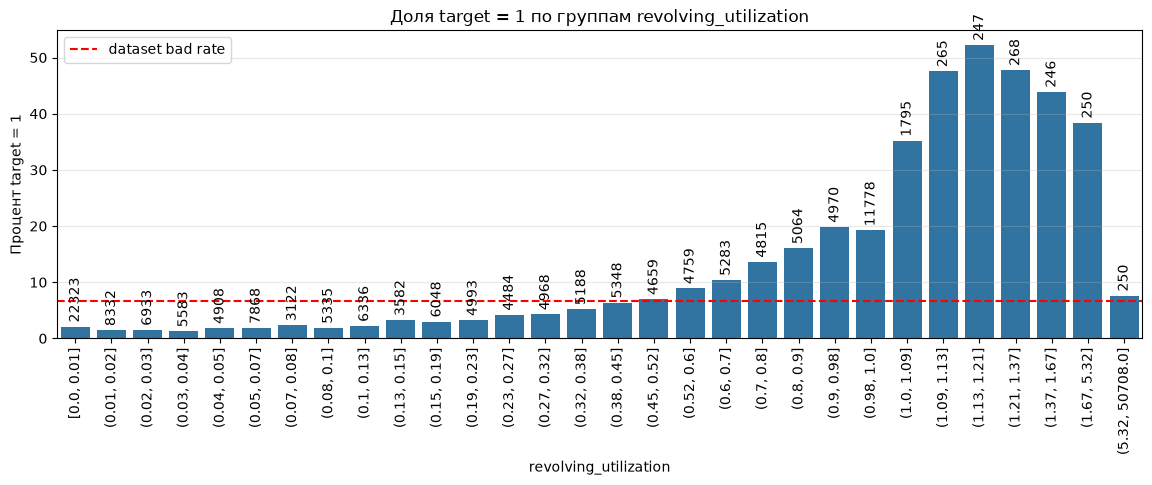

In [2517]:
plot_prebin_bad_rate_continuos_feature(
    data=data,
    feature="revolving_utilization"
)

Предварительные сегменты стоит укрупнить. Выполнять это будем опираясь на бизнес-значения самих сегментов и структуру их bad rate.

**Выделим следующие сегменты:**
1. [0.0, 0.2];
2. (0.2, 0.4];
3. (0.4, 0.5];
4. (0.5, 0.7];
5. (0.7, 1.0];
6. (1.0, 2.0];
7. (2.0, 5.0];
8. (5.0, np.inf]

Такие сегменты сохранят примерный уровень разделения риска по сегментам и будут иметь логичный бизнес-смысл (низкий, средний, высокий, overdraft, экстремальные и огромные значения).

In [2518]:
segments = [0.0, 0.2, 0.4, 0.5, 0.7, 1.0, 2.0, 5.0, np.inf]

**Построим отчёт по полученным сегментам и итоговый график.**

In [2519]:
revolving_utilization_segmented_data, revolving_utilization_report = make_segment_report_continuos_feature(
    data=data,
    feature="revolving_utilization",
    segments=segments,
    out_path="../data/risk_analysis/revolving_utilization/revolving_utilization_report.png"
)

In [2520]:
features_reports_names["revolving_utilization"] = "revolving_utilization_report"

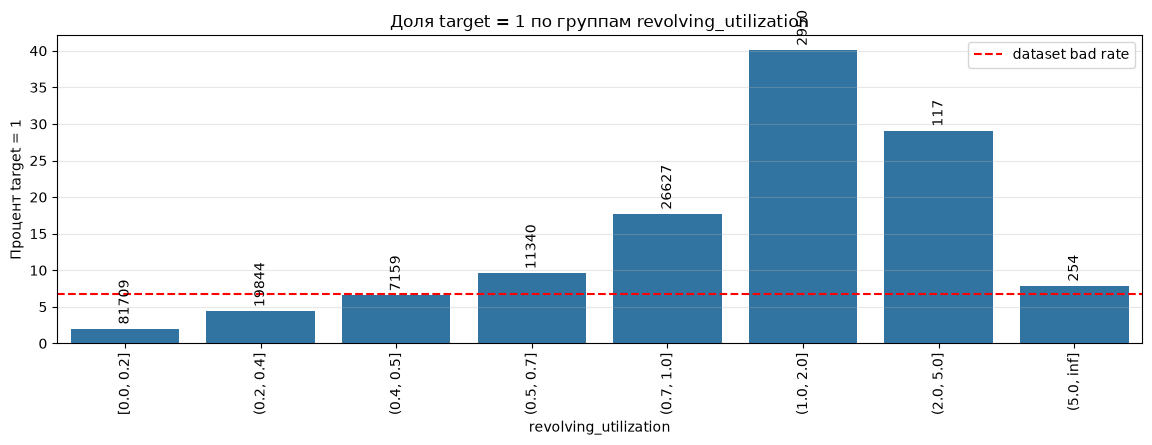

In [2521]:
plot_prebin_bad_rate_continuos_feature(
    data=data,
    feature="revolving_utilization",
    segments=segments,
    out_path="../data/risk_analysis/revolving_utilization/revolving_utilization_graphic.png"
)

In [2522]:
revolving_utilization_report

,segment,clients,dataset_share,dataset_bad_rate,bad_count,bad_share,bad_rate,ci_low,ci_high,delta_bad_rate_pp,lift
0,"[0.0, 0.2]",81709,0.5447,0.0668,1647,0.1643,0.0202,0.0192,0.0211,-4.6683,0.3016
1,"(0.2, 0.4]",19844,0.1323,0.0668,871,0.0869,0.0439,0.0411,0.0468,-2.2948,0.6567
2,"(0.4, 0.5]",7159,0.0477,0.0668,469,0.0468,0.0655,0.0600,0.0715,-0.1328,0.9801
3,"(0.5, 0.7]",11340,0.0756,0.0668,1085,0.1082,0.0957,0.0904,0.1012,2.8839,1.4315
4,"(0.7, 1.0]",26627,0.1775,0.0668,4717,0.4705,0.1772,0.1726,0.1818,11.0311,2.6504
5,"(1.0, 2.0]",2950,0.0197,0.0668,1183,0.1180,0.4010,0.3835,0.4188,33.4177,5.9997
6,"(2.0, 5.0]",117,0.0008,0.0668,34,0.0034,0.2906,0.2160,0.3785,22.3758,4.3477
7,"(5.0, inf]",254,0.0017,0.0668,20,0.0020,0.0787,0.0515,0.1185,1.1900,1.1780


Большинство сегментов содержит достаточно наблюдений, вследствие чего доверительные интервалы bad rate сравнительно узкие и оценки имеют хорошую статистическую точность.

Последний и предпоследний сегменты не объёмны, поэтому их оценка bad rate сильно теряет в точности.

**Оценим статистическую значимость сегментирования.**

In [2523]:
p_value, cramers_v = stat_power_segments(
    segmented_data=revolving_utilization_segmented_data,
    segment_col_name="revolving_utilization_segments",
    target_feature="target"
)

In [2524]:
p_value, cramers_v

(np.True_, np.float64(0.30270968759313227))

In [2525]:
features_connects_powers["revolving_utilization"] = f"{p_value}; {cramers_v}"

Схема оценивания силы связи.

In [2526]:
cramers_v_scheme

,Cramer's V,Эвристическая интерпретация
0,< 0.1,очень слабая
1,0.1-0.3,слабая
2,0.3-0.5,умеренная
3,> 0.5,сильная


Распределение target статистически различается между сегментами `revolving_utilization` ($\chi^{2}$ test, p < 0.001).

Cramer's V $\approx$ 0.30 указывает на заметную связь между сегментом utilization и target в исследуемой выборке.

**Вывод по признаку:**

У `revolving_utilization` наблюдается выраженная нелинейная связь с будущей серьёзной просрочкой. В диапазоне до 0.5 bad rate находится около или ниже по датасету, после чего риск заметно возрастает. Сегмент 0.7-1.0 составляет около 17.7% датасета, но формирует ~47.1% всех bad events; его bad rate равен 17.7%, что в 2.65 раза выше среднего. Наиболее высокий bad rate (~40%) наблюдается в диапазоне 1.0-2.0, однако этот сегмент значительно меньше - около 2% датасета. Диапазон 2.0-5.0 поддерживает высокий bad rate (~29%), но стоит учитывать малый объём сегмента ~0.08% датасета, хотя даже нижняя граница CI выше среднего bad rate в 3.1 раза. Для огромных значений, выше 5.0, связь исчезает: сегмент мал, CI широк, а bad rate близок к среднему по датасету, поэтому его стоит интерпретировать отдельно.

In [2527]:
risk_factor_notes.loc[ risk_factor_notes.shape[0] ] = [
    "revolving_utilization",
    "1. [0.0, 0.2]\n2. (0.2, 0.4]\n3. (0.4, 0.5]\n4. (0.5, 0.7]\n5. (0.7, 1.0]\n6. (1.0, 2.0]\n7. (2.0, 5.0]\n8. (5.0, inf]",
    "1. (0.5, 0.7] || 7.5% || 10.8% || 9.5%\n"
    "2. (0.7, 1.0] || 17.7% || 47.0% || 17.7%\n"
    "3. (1.0, 2.0] || 2.0% || 11.8% || 40.1%\n"
    "4. (2.0, 5.0] || 0.08% || 0.3% || 29.0%",
    "1. [0.0, 0.2] || 54.5% || 16.4% || 2.0%\n"
    "2. (0.2, 0.4] || 13.2% || 8.6% || 4.4%",
    "Сегменты (0.7, 1.0] и (1.0, 2.0] являются очень сильными маркерами риска, они формируют примерно 58% всех bad events, "
    "хотя составляют всего порядка 19% датасета.",
    "Сегменты (0.7, 1.0] и (1.0, 2.0] занимают примерно пятую часть датасета и половину bad "
    "events. Можно пробовать добавлять условия к этим достаточно объёмным сегментам и пытаться "
    "повышать bad rate более узкими условиями.",
    p_value,
    cramers_v
]

### `age`

**Построим график предварительных risk-сегментов.**

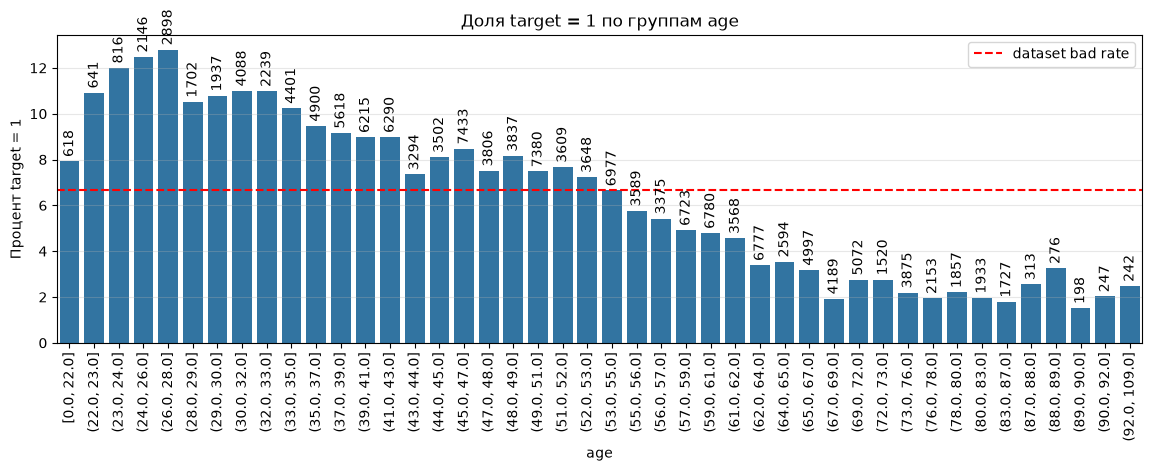

In [2528]:
plot_prebin_bad_rate_continuos_feature(
    data=data,
    feature="age"
)

Предварительные сегменты стоит укрупнить. Выполнять это будем опираясь на бизнес-значения самих сегментов и структуру их bad rate.

**Выделим следующие сегменты:**
1. [0.0, 22.0];
2. (22.0, 30.0];
3. (30.0, 45.0];
4. (45.0, 55.0];
5. (55.0, 75.0];
6. (75.0, np.inf]

Такие сегменты сохранят примерный уровень разделения риска по сегментам и будут иметь логичный бизнес-смысл (очень молодые, молодые, средний возраст, возрастные, пожилые, экстремальные).

In [2529]:
segments = [0.0, 22.0, 30.0, 45.0, 55.0, 75.0, np.inf]

**Построим отчёт по полученным сегментам и итоговый график.**

In [2530]:
age_segmented_data, age_report = make_segment_report_continuos_feature(
    data=data,
    feature="age",
    segments=segments,
    out_path="../data/risk_analysis/age/age_report.png"
)

In [2531]:
features_reports_names["age"] = "age_report"

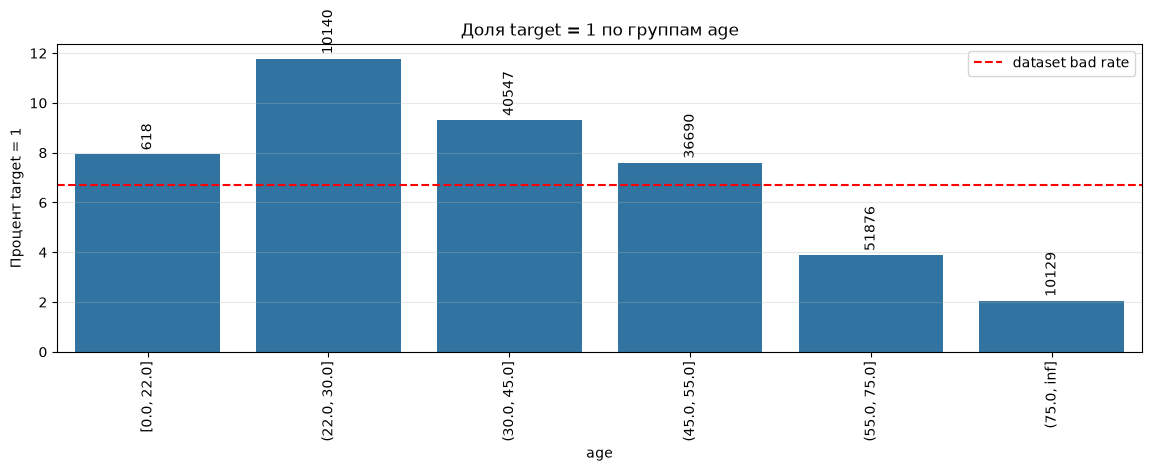

In [2532]:
plot_prebin_bad_rate_continuos_feature(
    data=data,
    feature="age",
    segments=segments,
    out_path="../data/risk_analysis/age/age_graphic.png"
)

In [2533]:
age_report

,segment,clients,dataset_share,dataset_bad_rate,bad_count,bad_share,bad_rate,ci_low,ci_high,delta_bad_rate_pp,lift
0,"[0.0, 22.0]",618,0.0041,0.0668,49,0.0049,0.0793,0.0605,0.1033,1.2448,1.1862
1,"(22.0, 30.0]",10140,0.0676,0.0668,1195,0.1192,0.1179,0.1117,0.1243,5.1010,1.7632
2,"(30.0, 45.0]",40547,0.2703,0.0668,3775,0.3765,0.0931,0.0903,0.0960,2.6262,1.3929
3,"(45.0, 55.0]",36690,0.2446,0.0668,2786,0.2779,0.0759,0.0733,0.0787,0.9093,1.1360
4,"(55.0, 75.0]",51876,0.3458,0.0668,2014,0.2009,0.0388,0.0372,0.0405,-2.8017,0.5808
5,"(75.0, inf]",10129,0.0675,0.0668,207,0.0206,0.0204,0.0179,0.0234,-4.6404,0.3058


Cегменты содержат достаточно наблюдений, вследствие чего доверительные интервалы bad rate сравнительно узкие и оценки имеют хорошую статистическую точность.

**Оценим статистическую значимость сегментирования.**

In [2534]:
p_value, cramers_v = stat_power_segments(
    segmented_data=age_segmented_data,
    segment_col_name="age_segments",
    target_feature="target"
)

In [2535]:
p_value, cramers_v

(np.True_, np.float64(0.11325690722975011))

In [2536]:
features_connects_powers["age"] = f"{p_value}; {cramers_v}"

Схема оценивания силы связи.

In [2537]:
cramers_v_scheme

,Cramer's V,Эвристическая интерпретация
0,< 0.1,очень слабая
1,0.1-0.3,слабая
2,0.3-0.5,умеренная
3,> 0.5,сильная


Распределение target статистически различается между сегментами `age` ($\chi^{2}$ test, p < 0.001).

Cramer's V $\approx$ 0.11 указывает на небольшую связь между сегментом age и target в исследуемой выборке.

**Вывод по признаку:**

У `age` наблюдается некоторая нелинейная связь с будущей серьёзной просрочкой. В диапазоне от до 22 лет bad rate находится немного выше по датасету, после чего риск начинает расти. В следующем сегменте, 22-30 лет, bad rate достигает своего пика ~11.8%, составляя при этом ~6.7% датасета и формируя ~12% всех bad events, превышая средний bad rate по датасету при этом в ~1.76 раза. В следующем сегменте, 30-45 лет, риск снижается, падая до ~9.3% и формируя ~37.6% всех bad events. В сегменте 45-55 лет bad rate падает ещё сильнее до ~7.6%, при этом сегмент формирует ~27.8% всех bad events. В последних двух сегментах bad rate достигает своего минимума - ~1.8%, составляя при этом 41.3% всего датасета и формируя всего 3.92% всех bad events.

In [2538]:
risk_factor_notes.loc[ risk_factor_notes.shape[0] ] = [
    "age",
    "1. [0.0, 22.0]\n2. (22.0, 30.0]\n3. (30.0, 45.0]\n4. (45.0, 55.0]\n5. (55.0, 75.0]\n6. (75.0, inf]",
    "1. (22.0, 30.0] || 6.7% || 11.9% || 11.7%\n"
    "2. (30.0, 45.0] || 27.0% || 37.6% || 9.3%",
    "1. [55.0, 75.0] || 34.6% || 20.1% || 3.8%\n"
    "2. (75.0, inf] || 6.7% || 2.0% || 2.0%",
    "Сегменты (22.0, 30.0] и (30.0, 45.0] являются не очень сильными маркерами риска, они формируют примерно 49% всех bad events, "
    "но составляют при этом примерно 34% датасета.",
    "Сегменты (22.0, 30.0] и (30.0, 45.0] занимают примерно треть датасета и половину bad "
    "events. Можно пробовать добавлять условия к этим достаточно объёмным сегментам и пытаться "
    "повышать bad rate более узкими условиями.",
    p_value,
    cramers_v
]

### `num_30_59_days_late`

**Построим график предварительных risk-сегментов.**

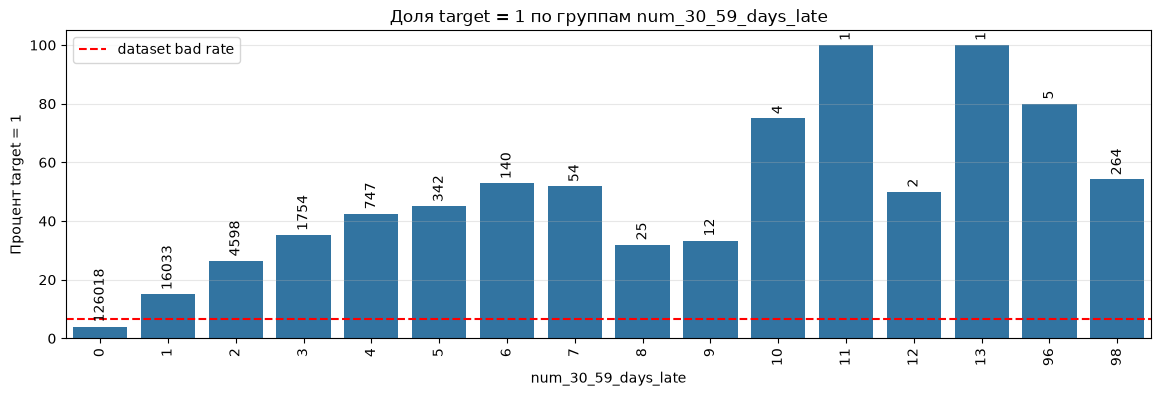

In [2539]:
plot_prebin_bad_rate_count_or_cat_feature(
    data=data,
    feature="num_30_59_days_late",
    special_values=[96, 98]
)

Предварительные сегменты стоит укрупнить. Выполнять это будем опираясь на бизнес-значения самих сегментов и структуру их bad rate.

**Выделим следующие сегменты:**
1. 0;
2. [1, 2];
3. (2, np.inf];
4. 96;
5. 98.

Такие сегменты сохранят примерный уровень разделения риска по сегментам и будут иметь логичный бизнес-смысл (нет, одна, больше 1).

In [2540]:
segments = [1, 2, 13]

**Построим отчёт по полученным сегментам и итоговый график.**

In [2541]:
num_30_59_days_late_segmented_data, num_30_59_days_late_report = make_segment_report_count_or_cat_feature(
    data=data,
    feature="num_30_59_days_late",
    special_values=[96, 98],
    segments=segments,
    out_path="../data/risk_analysis/num_30_59_days_late/num_30_59_days_late_report.png"
)

In [2542]:
features_reports_names["num_30_59_days_late"] = "num_30_59_days_late_report"

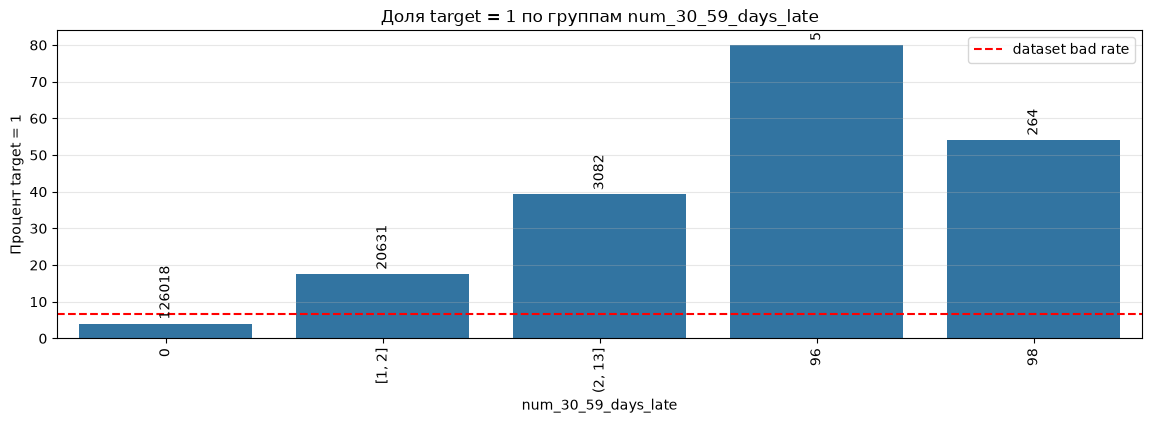

In [2543]:
plot_prebin_bad_rate_count_or_cat_feature(
    data=data,
    feature="num_30_59_days_late",
    special_values=[96, 98],
    segments=segments,
    out_path="../data/risk_analysis/num_30_59_days_late/num_30_59_days_late_graphic.png"
)

In [2544]:
num_30_59_days_late_report

,segment,clients,dataset_share,dataset_bad_rate,bad_count,bad_share,bad_rate,ci_low,ci_high,delta_bad_rate_pp,lift
0,0,126018,0.8401,0.0668,5041,0.5028,0.0400,0.0389,0.0411,-2.6838,0.5985
1,"[1, 2]",20631,0.1375,0.0668,3628,0.3619,0.1759,0.1707,0.1811,10.9012,2.6309
2,"(2, 13]",3082,0.0205,0.0668,1210,0.1207,0.3926,0.3755,0.4100,32.5762,5.8738
3,96,5,0.0000,0.0668,4,0.0004,0.8000,0.3755,0.9638,73.3160,11.9689
4,98,264,0.0018,0.0668,143,0.0143,0.5417,0.4814,0.6007,47.4827,8.1039


Большинство сегментов содержит достаточно наблюдений, вследствие чего доверительные интервалы bad rate сравнительно узкие и оценки имеют хорошую статистическую точность.

Последний и предпоследний сегменты не объёмны, поэтому их оценка bad rate сильно теряет в точности. Тем не менее, данные сегменты необходимы исходя из бизнес логики (предположительно системные коды).

**Оценим статистическую значимость сегментирования.**

In [2545]:
p_value, cramers_v = stat_power_segments(
    segmented_data=num_30_59_days_late_segmented_data,
    segment_col_name="num_30_59_days_late_segments",
    target_feature="target"
)

In [2546]:
p_value, cramers_v

(np.True_, np.float64(0.27841348860176934))

In [2547]:
features_connects_powers["num_30_59_days_late"] = f"{p_value}; {cramers_v}"

Схема оценивания силы связи.

In [2548]:
cramers_v_scheme

,Cramer's V,Эвристическая интерпретация
0,< 0.1,очень слабая
1,0.1-0.3,слабая
2,0.3-0.5,умеренная
3,> 0.5,сильная


Распределение target статистически различается между сегментами `num_30_59_days_late` ($\chi^{2}$ test, p < 0.001).

Cramer's V $\approx$ 0.278 указывает на заметную связь между сегментом num_30_59_days_late и target в исследуемой выборке.

**Вывод по признаку:**

У `num_30_59_days_late` наблюдается выраженная нелинейная связь с будущей серьёзной просрочкой. У людей без краткосрочных просрочек bad rate находится ниже по датасету, после чего риск заметно возрастает. Сегмент 1-2 составляет около 13.7% датасета, но формирует ~36.2% всех bad events; его bad rate равен ~17.6%, что в 2.63 раза выше среднего. Далее bad rate растёт ещё сильнее, достигая ~39.2%, в диапазоне (2, 13], однако данный сегмент значительно меньше - около 2% датасета. Сегменты системных кодов имеют очень высокий bad rate ~80%, ~54% соответственно, но стоит учитывать малые объёмы сегментов, которые делают оценку bad rate в них крайне неточной.

In [2549]:
risk_factor_notes.loc[ risk_factor_notes.shape[0] ] = [
    "num_30_59_days_late",
    "1. 0\n2. [1, 2]\n3. (2, 13]\n4. 96\n5. 98",
    "1. [1, 2] || 13.7% || 36.1% || 11.6%\n"
    "2. (2, 13] || 2.0% || 12.0% || 39.2%\n"
    "3. 96 || 0% || 0.04% || 80.0%\n"
    "4. 98 || 0.18% || 1.4% || 54.1%",
    "1. 0 || 84.0% || 50.2% || 4.0%",
    "Сегменты [1, 2] и (2, 13] являются очень сильными маркерами риска, они формируют примерно 48% всех bad events, "
    "хотя составляют при этом всего 16% датасета.",
    "Сегмент [1, 2] занимает примерно 13.% датасета и треть bad "
    "events. Можно пробовать добавлять условия к этому сегментаму и пытаться "
    "повысить bad rate сузив его дополнительными условиями.",
    p_value,
    cramers_v
]

### `num_60_89_days_late`

**Построим график предварительных risk-сегментов.**

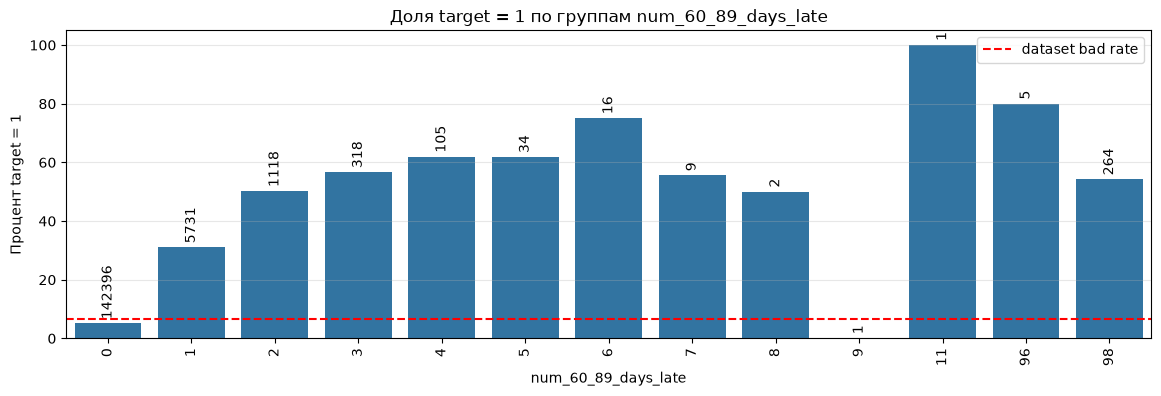

In [2550]:
plot_prebin_bad_rate_count_or_cat_feature(
    data=data,
    feature="num_60_89_days_late",
    special_values=[96, 98]
)

Предварительные сегменты стоит укрупнить. Выполнять это будем опираясь на бизнес-значения самих сегментов и структуру их bad rate.

**Выделим следующие сегменты:**
1. 0;
2. [1, 2];
3. (2, np.inf];
4. 96;
5. 98.

Такие сегменты сохранят примерный уровень разделения риска по сегментам и будут иметь логичный бизнес-смысл (нет, одна, больше 1).

In [2551]:
segments = [1, 2, 11]

**Построим отчёт по полученным сегментам и итоговый график.**

In [2552]:
num_60_89_days_late_segmented_data, num_60_89_days_late_report = make_segment_report_count_or_cat_feature(
    data=data,
    feature="num_60_89_days_late",
    special_values=[96, 98],
    segments=segments,
    out_path="../data/risk_analysis/num_60_89_days_late/num_60_89_days_late_report.png"
)

In [2553]:
features_reports_names["num_60_89_days_late"] = "num_60_89_days_late_report"

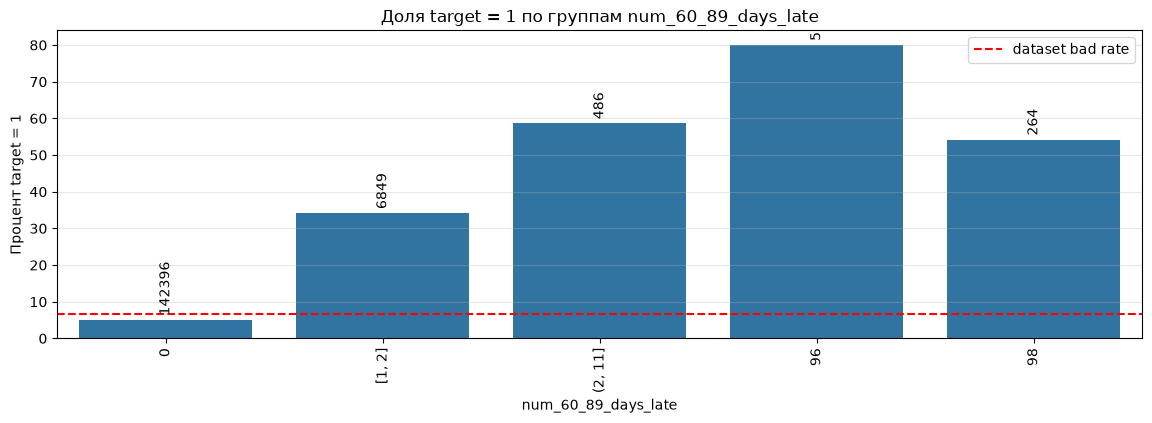

In [2554]:
plot_prebin_bad_rate_count_or_cat_feature(
    data=data,
    feature="num_60_89_days_late",
    special_values=[96, 98],
    segments=segments,
    out_path="../data/risk_analysis/num_60_89_days_late/num_60_89_days_late_graphic.png"
)

In [2555]:
num_60_89_days_late_report

,segment,clients,dataset_share,dataset_bad_rate,bad_count,bad_share,bad_rate,ci_low,ci_high,delta_bad_rate_pp,lift
0,0,142396,0.9493,0.0668,7256,0.7237,0.0510,0.0498,0.0521,-1.5884,0.7624
1,"[1, 2]",6849,0.0457,0.0668,2338,0.2332,0.3414,0.3302,0.3527,27.4524,5.1072
2,"(2, 11]",486,0.0032,0.0668,285,0.0284,0.5864,0.5421,0.6294,51.9580,8.7735
3,96,5,0.0000,0.0668,4,0.0004,0.8000,0.3755,0.9638,73.3160,11.9689
4,98,264,0.0018,0.0668,143,0.0143,0.5417,0.4814,0.6007,47.4827,8.1039


Большинство сегментов содержит достаточно наблюдений, вследствие чего доверительные интервалы bad rate сравнительно узкие и оценки имеют хорошую статистическую точность.

Последний и предпоследний сегменты не объёмны, поэтому их оценка bad rate сильно теряет в точности. Тем не менее, данные сегменты необходимы исходя из бизнес логики (предположительно системные коды).

**Оценим статистическую значимость сегментирования.**

In [2556]:
p_value, cramers_v = stat_power_segments(
    segmented_data=num_60_89_days_late_segmented_data,
    segment_col_name="num_60_89_days_late_segments",
    target_feature="target"
)

In [2557]:
p_value, cramers_v

(np.True_, np.float64(0.282280935238293))

In [2558]:
features_connects_powers["num_60_89_days_late"] = f"{p_value}; {cramers_v}"

Схема оценивания силы связи.

In [2559]:
cramers_v_scheme

,Cramer's V,Эвристическая интерпретация
0,< 0.1,очень слабая
1,0.1-0.3,слабая
2,0.3-0.5,умеренная
3,> 0.5,сильная


Распределение target статистически различается между сегментами `num_60_89_days_late` ($\chi^{2}$ test, p < 0.001).

Cramer's V $\approx$ 0.282 указывает на заметную связь между сегментом num_60_89_days_late и target в исследуемой выборке.

**Вывод по признаку:**

У `num_60_89_days_late` наблюдается выраженная нелинейная связь с будущей серьёзной просрочкой. У людей без среднесрочных просрочек bad rate находится ниже по датасету, после чего риск заметно возрастает. Сегмент 1-2 составляет около 4.6% датасета, но формирует ~23.3% всех bad events; его bad rate равен ~34.1%, что в 5.1 раза выше среднего. Далее bad rate растёт ещё сильнее, достигая ~58.6%, в диапазоне (2, 11], однако данный сегмент значительно меньше - около 0.3% датасета. Сегменты системных кодов имеют очень высокий bad rate ~80%, ~54% соответственно, но стоит учитывать малые объёмы сегментов, которые делают оценку bad rate в них крайне неточной.

In [2560]:
risk_factor_notes.loc[ risk_factor_notes.shape[0] ] = [
    "num_60_89_days_late",
    "1. 0\n2. [1, 2]\n3. (2, 11]\n4. 96\n5. 98",
    "1. [1, 2] || 4.6% || 23.3% || 34.1%\n"
    "2. (2, 11] || 0.3% || 2.8% || 58.6%\n"
    "3. 96 || 0% || 0.04% || 80.0%\n"
    "4. 98 || 0.18% || 1.4% || 54.1%",
    "1. 0 || 95.0% || 72.3% || 5.1%",
    "Сегменты [1, 2] и (2, 11] являются очень сильными маркерами риска, пусть они и составляют примерно 4.6% датасета, "
    "но формируют целых 23.3% всех bad events, а также имеют крайне высокий уровень риска (34.1%, 58.6% соответственно).",
    "-",
    p_value,
    cramers_v
]

### `num_90_days_late`

**Построим график предварительных risk-сегментов.**

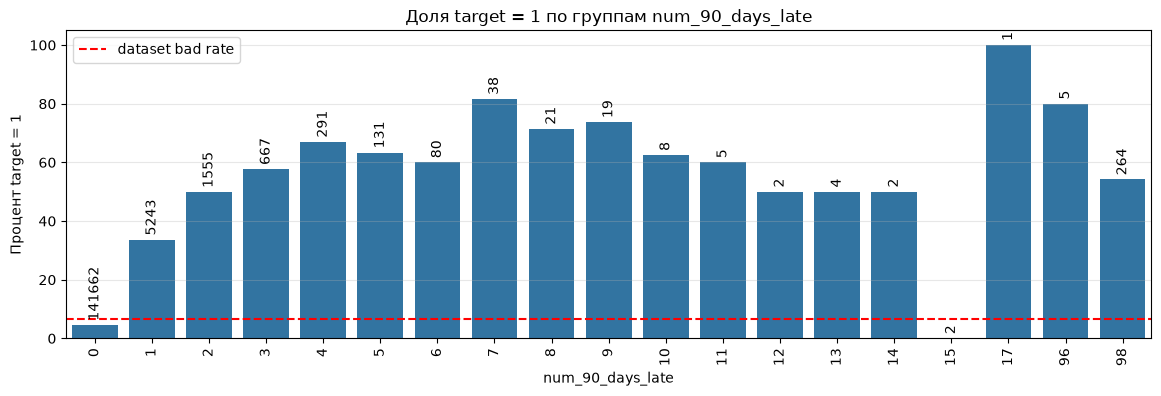

In [2561]:
plot_prebin_bad_rate_count_or_cat_feature(
    data=data,
    feature="num_90_days_late",
    special_values=[96, 98]
)

Предварительные сегменты стоит укрупнить. Выполнять это будем опираясь на бизнес-значения самих сегментов и структуру их bad rate.

**Выделим следующие сегменты:**
1. 0;
2. [1, 2];
3. (2, np.inf];
4. 96;
5. 98.

Такие сегменты сохранят примерный уровень разделения риска по сегментам и будут иметь логичный бизнес-смысл (нет, одна, больше 1).

In [2562]:
segments = [1, 2, 17]

**Построим отчёт по полученным сегментам и итоговый график.**

In [2563]:
num_90_days_late_segmented_data, num_90_days_late_report = make_segment_report_count_or_cat_feature(
    data=data,
    feature="num_90_days_late",
    special_values=[96, 98],
    segments=segments,
    out_path="../data/risk_analysis/num_90_days_late/num_90_days_late_report.png"
)

In [2564]:
features_reports_names["num_90_days_late"] = "num_90_days_late_report"

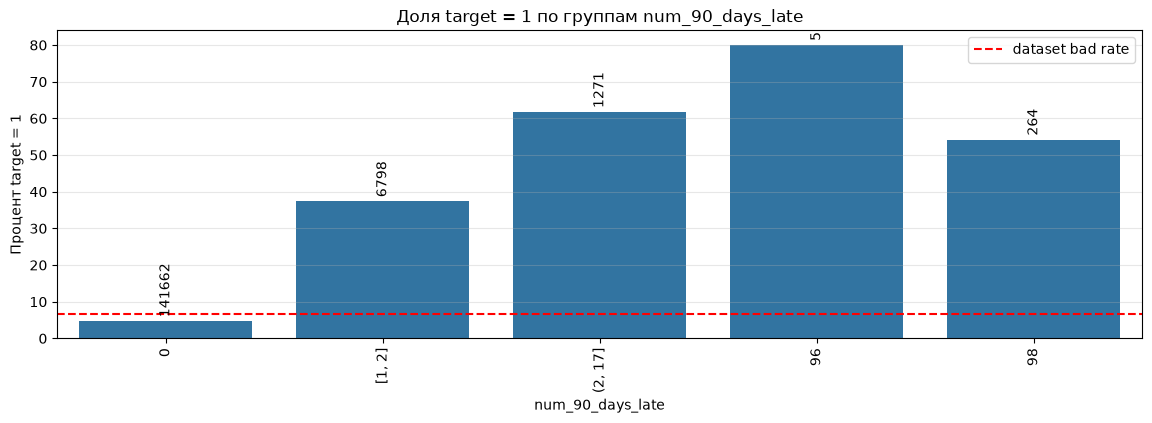

In [2565]:
plot_prebin_bad_rate_count_or_cat_feature(
    data=data,
    feature="num_90_days_late",
    special_values=[96, 98],
    segments=segments,
    out_path="../data/risk_analysis/num_90_days_late/num_90_days_late_graphic.png"
)

In [2566]:
num_90_days_late_report

,segment,clients,dataset_share,dataset_bad_rate,bad_count,bad_share,bad_rate,ci_low,ci_high,delta_bad_rate_pp,lift
0,0,141662,0.9444,0.0668,6554,0.6537,0.0463,0.0452,0.0474,-2.0575,0.6922
1,"[1, 2]",6798,0.0453,0.0668,2541,0.2534,0.3738,0.3624,0.3854,30.6946,5.5923
2,"(2, 17]",1271,0.0085,0.0668,784,0.0782,0.6168,0.5898,0.6432,54.9997,9.2286
3,96,5,0.0000,0.0668,4,0.0004,0.8000,0.3755,0.9638,73.3160,11.9689
4,98,264,0.0018,0.0668,143,0.0143,0.5417,0.4814,0.6007,47.4827,8.1039


Большинство сегментов содержит достаточно наблюдений, вследствие чего доверительные интервалы bad rate сравнительно узкие и оценки имеют хорошую статистическую точность.

Последний и предпоследний сегменты не объёмны, поэтому их оценка bad rate сильно теряет в точности. Тем не менее, данные сегменты необходимы исходя из бизнес логики (предположительно системные коды).

**Оценим статистическую значимость сегментирования.**

In [2567]:
p_value, cramers_v = stat_power_segments(
    segmented_data=num_90_days_late_segmented_data,
    segment_col_name="num_90_days_late_segments",
    target_feature="target"
)

In [2568]:
p_value, cramers_v

(np.True_, np.float64(0.35015878202705747))

In [2569]:
features_connects_powers["num_90_days_late"] = f"{p_value}; {cramers_v}"

Схема оценивания силы связи.

In [2570]:
cramers_v_scheme

,Cramer's V,Эвристическая интерпретация
0,< 0.1,очень слабая
1,0.1-0.3,слабая
2,0.3-0.5,умеренная
3,> 0.5,сильная


Распределение target статистически различается между сегментами `num_90_days_late` ($\chi^{2}$ test, p < 0.001).

Cramer's V $\approx$ 0.35 указывает на заметную связь между сегментом num_90_days_late и target в исследуемой выборке.

**Вывод по признаку:**

У `num_90_days_late` наблюдается выраженная нелинейная связь с будущей серьёзной просрочкой. У людей без среднесрочных просрочек bad rate находится ниже по датасету, после чего риск заметно возрастает. Сегмент 1-2 составляет около 4.5% датасета, но формирует ~25.3% всех bad events; его bad rate равен ~37.3%, что в 5.5 раза выше среднего. Далее bad rate растёт ещё сильнее, достигая ~61.6%, в диапазоне (2, 17], однако данный сегмент значительно меньше - около 0.85% датасета. Сегменты системных кодов имеют очень высокий bad rate ~80%, ~54% соответственно, но стоит учитывать малые объёмы сегментов, которые делают оценку bad rate в них крайне неточной.

In [2571]:
risk_factor_notes.loc[ risk_factor_notes.shape[0] ] = [
    "num_90_days_late",
    "1. 0\n2. [1, 2]\n3. (2, 17]\n4. 96\n5. 98",
    "1. [1, 2] || 4.5% || 25.3% || 37.3%\n"
    "2. (2, 17] || 0.8% || 7.8% || 61.6%\n"
    "3. 96 || 0% || 0.04% || 80.0%\n"
    "4. 98 || 0.18% || 1.4% || 54.1%",
    "1. 0 || 94.0% || 65.3% || 4.6%",
    "Сегменты [1, 2] и (2, 17] являются очень сильными маркерами риска, пусть они и составляют примерно 5.4% датасета, "
    "но формируют целых 33% всех bad events, а также имеют крайне высокий уровень риска (37.4%, 61.6% соответственно).",
    "-",
    p_value,
    cramers_v
]

### `debt_ratio`

**Построим график предварительных risk-сегментов.**

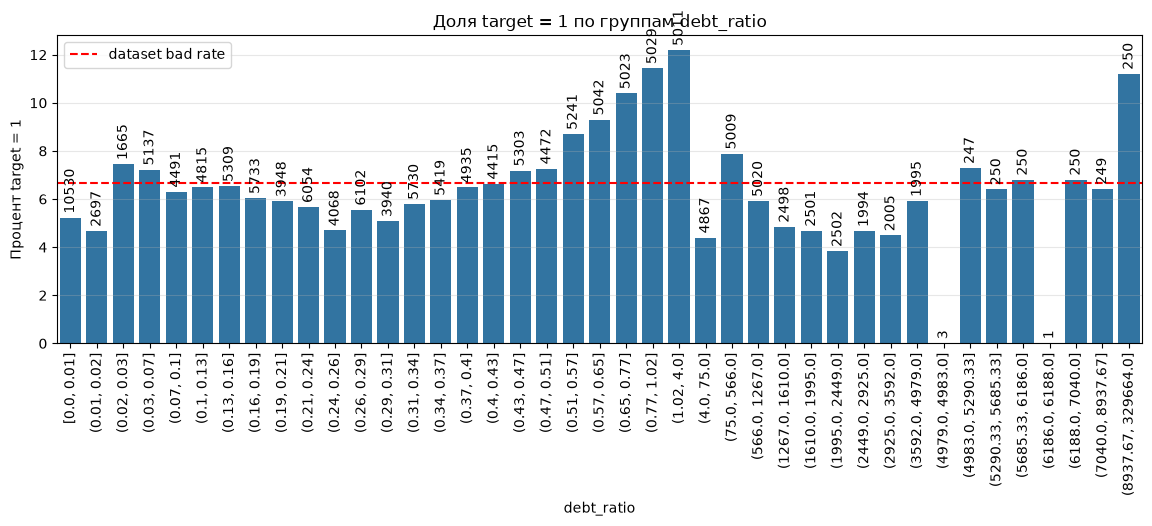

In [2572]:
plot_prebin_bad_rate_continuos_feature(
    data=data,
    feature="debt_ratio"
)

Предварительные сегменты стоит укрупнить. Выполнять это будем опираясь на бизнес-значения самих сегментов и структуру их bad rate.

**Выделим следующие сегменты:**
1. [0.0, 0.1];
2. (0.1, 0.7];
3. (0.7, 1.0];
4. (1.0, 4.0];
5. (4.0, np.inf].

Такие сегменты сохранят примерный уровень разделения риска по сегментам и будут иметь логичный бизнес-смысл (низкий, средний, высокий, экстремальные, огромные значения).

In [2573]:
segments = [0.0, 0.1, 0.7, 1.0, 4.0, np.inf]

**Построим отчёт по полученным сегментам и итоговый график.**

In [2574]:
debt_ratio_segmented_data, debt_ratio_report = make_segment_report_continuos_feature(
    data=data,
    feature="debt_ratio",
    segments=segments,
    out_path="../data/risk_analysis/debt_ratio/debt_ratio_report.png"
)

In [2575]:
features_reports_names["debt_ratio"] = "debt_ratio_report"

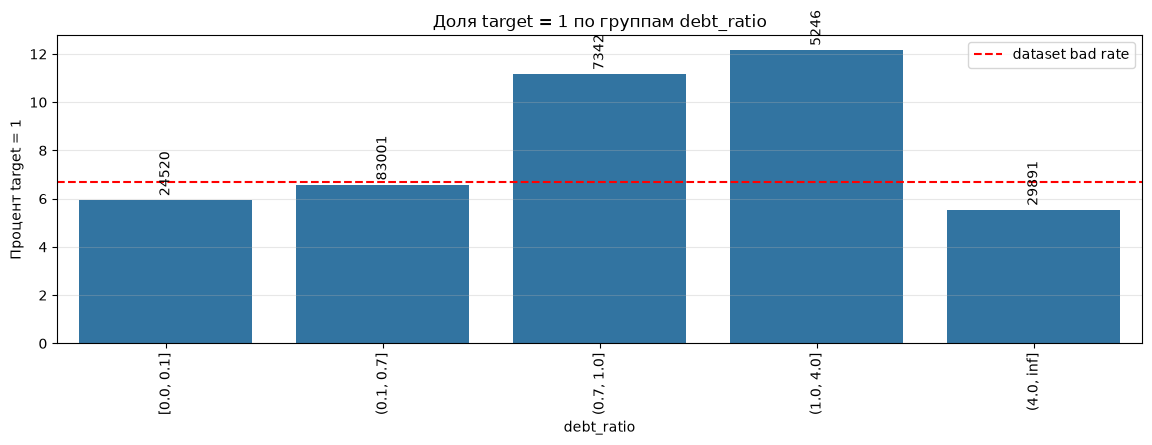

In [2576]:
plot_prebin_bad_rate_continuos_feature(
    data=data,
    feature="debt_ratio",
    segments=segments,
    out_path="../data/risk_analysis/debt_ratio/debt_ratio_graphic.png"
)

In [2577]:
debt_ratio_report

,segment,clients,dataset_share,dataset_bad_rate,bad_count,bad_share,bad_rate,ci_low,ci_high,delta_bad_rate_pp,lift
0,"[0.0, 0.1]",24520,0.1635,0.0668,1454,0.1450,0.0593,0.0564,0.0623,-0.7541,0.8872
1,"(0.1, 0.7]",83001,0.5533,0.0668,5462,0.5448,0.0658,0.0641,0.0675,-0.1034,0.9845
2,"(0.7, 1.0]",7342,0.0489,0.0668,819,0.0817,0.1115,0.1046,0.1190,4.4710,1.6689
3,"(1.0, 4.0]",5246,0.0350,0.0668,638,0.0636,0.1216,0.1130,0.1307,5.4776,1.8195
4,"(4.0, inf]",29891,0.1993,0.0668,1653,0.1649,0.0553,0.0528,0.0579,-1.1539,0.8274


Сегменты содержат достаточно наблюдений, вследствие чего доверительные интервалы bad rate сравнительно узкие и оценки имеют хорошую статистическую точность.

**Оценим статистическую значимость сегментирования.**

In [2578]:
p_value, cramers_v = stat_power_segments(
    segmented_data=debt_ratio_segmented_data,
    segment_col_name="debt_ratio_segments",
    target_feature="target"
)

In [2579]:
p_value, cramers_v

(np.True_, np.float64(0.061927744461841135))

In [2580]:
features_connects_powers["debt_ratio"] = f"{p_value}; {cramers_v}"

Схема оценивания силы связи.

In [2581]:
cramers_v_scheme

,Cramer's V,Эвристическая интерпретация
0,< 0.1,очень слабая
1,0.1-0.3,слабая
2,0.3-0.5,умеренная
3,> 0.5,сильная


Распределение target статистически различается между сегментами `debt_ratio` ($\chi^{2}$ test, p < 0.001).

Cramer's V $\approx$ 0.06 указывает на очень слабую связь между сегментом debt_ratio и target в исследуемой выборке.

**Вывод по признаку:**

У `debt_ratio` наблюдается очень слабая нелинейная связь с будущей серьёзной просрочкой. В диапазон до 0.7 bad rate находится около или ниже по датасету, но формируя при этом ~69% всех bad events, после чего риск возрастает. Сегмент 0.7-1.0 достигает значения bad rate ~11.1%, но составляя и формируя ~4.8% и ~8.1% датасета, bad rate соответственно. В сегменте 1.0-4.0 риск достигает своего пика ~12.1% bad tate, но стаставляет только ~3.5% датасета и формирует только ~6.3% всех bad events. В сегменте экстремальных значений >4.0 bad rate падает до ~5.5%, хотя составляет ~19.3% датасета и формируя при этом ~16.5% всех bad events.

In [2582]:
risk_factor_notes.loc[ risk_factor_notes.shape[0] ] = [
    "debt_ratio",
    "1. [0.0, 0.1]\n2. (0.1, 0.7]\n3. (0.7, 1.0]\n4. (1.0, 4.0]\n5. (4.0, inf]",
    "1. (0.7, 1.0] || 4.9% || 8.1% || 11.1%\n"
    "2. (1.0, 4.0] || 3.5% || 6.3% || 12.1%",
    "-",
    "Сегменты (0.7, 1.0] и (1.0, 4.0] не являются сильными маркерами риска, по ним нельзя делать выводы.",
    "Сегменты (0.7, 1.0] и (1.0, 4.0] не являются сильными маркерами, но их можно попробовать в "
    "качестве дополнительных условий в interaction analysis.",
    p_value,
    cramers_v
]

### `monthly_income`

**Построим график предварительных risk-сегментов.**

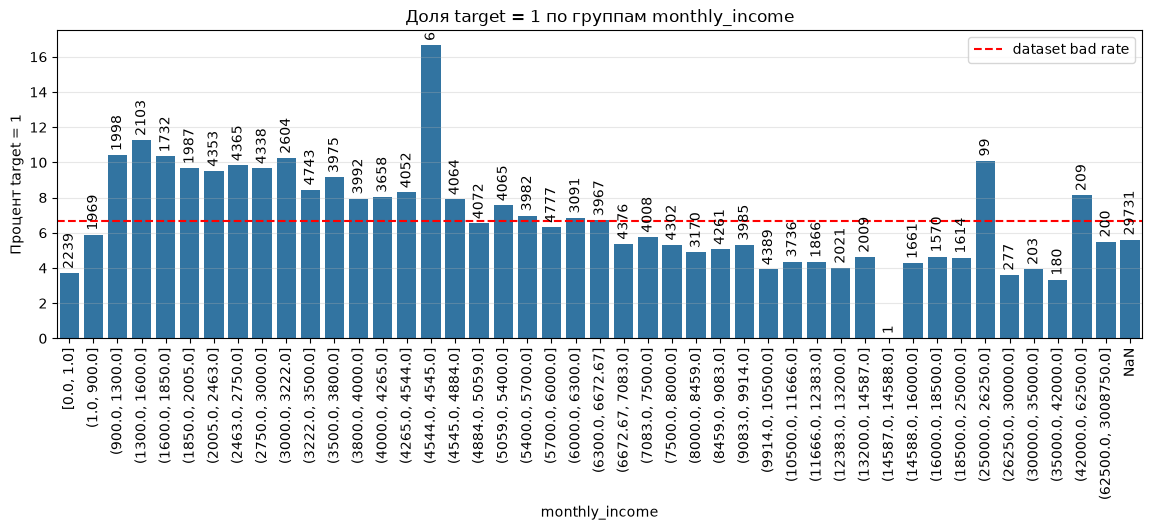

In [2583]:
plot_prebin_bad_rate_continuos_feature(
    data=data,
    feature="monthly_income",
    special_values=[np.nan]
)

Предварительные сегменты стоит укрупнить. Выполнять это будем опираясь на бизнес-значения самих сегментов и структуру их bad rate.

**Выделим следующие сегменты:**
1. [0.0, 900.0];
2. (900.0, 3000.0];
3. (3000.0, 4500.0];
4. (4500.0, 6500.0];
5. (6500.0, 13000.0];
6. (13000.0, np.inf];
7. Nan.

Такие сегменты сохранят примерный уровень разделения риска по сегментам и будут иметь логичный бизнес-смысл (низкий, средний, высокий, экстремальные, огромные значения).

In [2584]:
segments = [0.0, 900.0, 3000.0, 4500.0, 6500.0, 13000.0, np.inf]

**Построим отчёт по полученным сегментам и итоговый график.**

In [2585]:
monthly_income_segmented_data, monthly_income_report = make_segment_report_continuos_feature(
    data=data,
    feature="monthly_income",
    segments=segments,
    special_values=[np.nan],
    out_path="../data/risk_analysis/monthly_income/monthly_income_report.png"
)

In [2586]:
features_reports_names["monthly_income"] = "monthly_income_report"

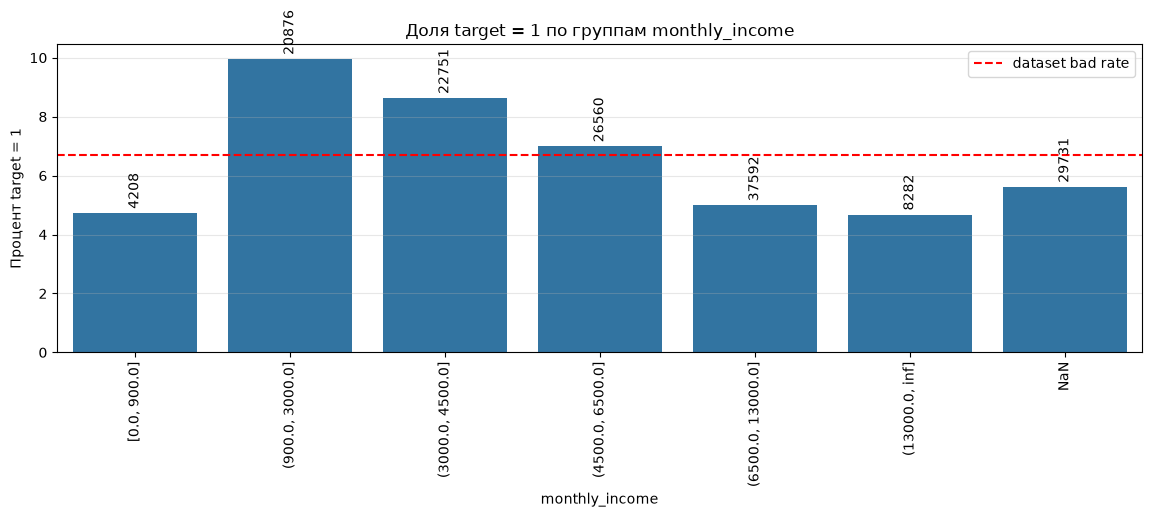

In [2587]:
plot_prebin_bad_rate_continuos_feature(
    data=data,
    feature="monthly_income",
    segments=segments,
    special_values=[np.nan],
    out_path="../data/risk_analysis/monthly_income/monthly_income_graphic.png"
)

In [2588]:
monthly_income_report

,segment,clients,dataset_share,dataset_bad_rate,bad_count,bad_share,bad_rate,ci_low,ci_high,delta_bad_rate_pp,lift
0,"[0.0, 900.0]",4208,0.0281,0.0668,199,0.0198,0.0473,0.0413,0.0541,-1.9549,0.7075
1,"(900.0, 3000.0]",20876,0.1392,0.0668,2078,0.2073,0.0995,0.0956,0.1037,3.2700,1.4892
2,"(3000.0, 4500.0]",22751,0.1517,0.0668,1963,0.1958,0.0863,0.0827,0.0900,1.9442,1.2909
3,"(4500.0, 6500.0]",26560,0.1771,0.0668,1856,0.1851,0.0699,0.0669,0.0730,0.3040,1.0455
4,"(6500.0, 13000.0]",37592,0.2506,0.0668,1874,0.1869,0.0499,0.0477,0.0521,-1.6989,0.7458
5,"(13000.0, inf]",8282,0.0552,0.0668,387,0.0386,0.0467,0.0424,0.0515,-2.0112,0.6991
6,NaN,29731,0.1982,0.0668,1669,0.1665,0.0561,0.0536,0.0588,-1.0703,0.8399


Сегменты содержат достаточно наблюдений, вследствие чего доверительные интервалы bad rate сравнительно узкие и оценки имеют хорошую статистическую точность.

**Оценим статистическую значимость сегментирования.**

In [2589]:
p_value, cramers_v = stat_power_segments(
    segmented_data=monthly_income_segmented_data,
    segment_col_name="monthly_income_segments",
    target_feature="target"
)

In [2590]:
p_value, cramers_v

(np.True_, np.float64(0.0733829873882263))

In [2591]:
features_connects_powers["monthly_income"] = f"{p_value}; {cramers_v}"

Схема оценивания силы связи.

In [2592]:
cramers_v_scheme

,Cramer's V,Эвристическая интерпретация
0,< 0.1,очень слабая
1,0.1-0.3,слабая
2,0.3-0.5,умеренная
3,> 0.5,сильная


Распределение target статистически различается между сегментами `monthly_income` ($\chi^{2}$ test, p < 0.001).

Cramer's V $\approx$ 0.073 указывает на очень слабую связь между сегментом monthly_income и target в исследуемой выборке.

**Вывод по признаку:**

У `monthly_income` наблюдается очень слабая нелинейная связь с будущей серьёзной просрочкой. В диапазон до 900 bad rate находится ниже по датасету, сам сегмент небольшой - ~2.8% датасета и ~2% всех bad events. В следующих сегментах (900-6500) риск возрастает. Сегменты 900-6500 имеют несколько повышенный риск - bad rate от ~7% до ~10.0%, при этом данные сегменты составляют ~46.8% (от 13 до 17 процентов на сегмент) и формируют ~58.8% всех bad events (от 18 до 20 процентов на сегмент). В следующих сегментах риск снижается, падая до ~4.6% (~5%, ~4.6%, ~5.6% соответственно), составляя при этом ~50% датасета и формируя ~39% всех bad events.

In [2593]:
risk_factor_notes.loc[ risk_factor_notes.shape[0] ] = [
    "monthly_income",
    "1. [0.0, 900.0]\n2. (900.0, 3000.0]\n3. (3000.0, 4500.0]\n4. (4500.0, 6500.0]\n5. (6500.0, 13000.0]\n6. (13000.0, inf]\n7. NaN",
    "1. (900.0, 3000.0] || 13.9% || 20.7% || 10.0%\n"
    "2. (3000.0, 4500.0] || 15.1% || 19.6% || 8.6%",
    "-",
    "Сегменты (900.0, 3000.0] и (3000.0, 4500.0] можно принять за слабые маркеры. В совокупности они составляют "
    "примерно 30% датасета и формируют 40% всех bad events, но тем не менее bad rate у них не высок.",
    "Сегменты (900.0, 3000.0] и (3000.0, 4500.0] можно сужать и уточнять, так как они занимают 30% датасета "
    "и формируют 40% всех bad events, но имеют bad rate всего порядка 9%.",
    p_value,
    cramers_v
]

### `num_open_credit_lines`

**Построим график предварительных risk-сегментов.**

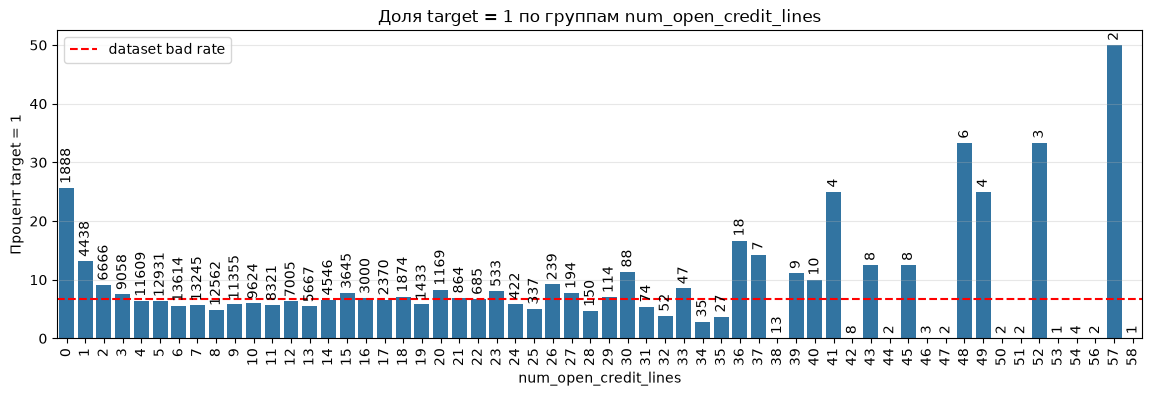

In [2594]:
plot_prebin_bad_rate_count_or_cat_feature(
    data=data,
    feature="num_open_credit_lines"
)

Предварительные сегменты стоит укрупнить. Выполнять это будем опираясь на бизнес-значения самих сегментов и структуру их bad rate.

**Выделим следующие сегменты:**
1. 0;
2. [1, 2];
3. (2, np.inf].

Такие сегменты сохранят примерный уровень разделения риска по сегментам и будут иметь логичный бизнес-смысл (нет, одна, больше 1).

In [2595]:
segments = [1, 2, 58]

**Построим отчёт по полученным сегментам и итоговый график.**

In [2596]:
num_open_credit_lines_segmented_data, num_open_credit_lines_report = make_segment_report_count_or_cat_feature(
    data=data,
    feature="num_open_credit_lines",
    segments=segments,
    out_path="../data/risk_analysis/num_open_credit_lines/num_open_credit_lines_report.png"
)

In [2597]:
features_reports_names["num_open_credit_lines"] = "num_open_credit_lines_report"

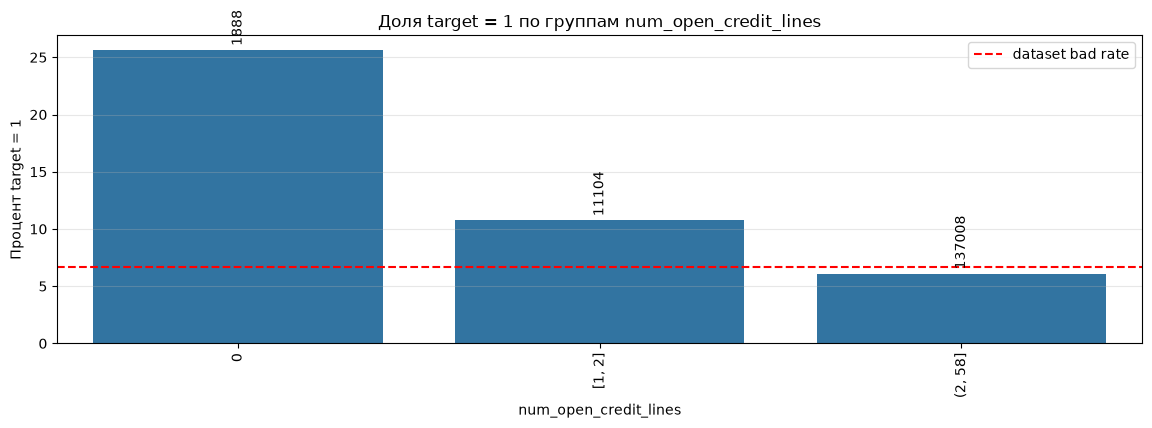

In [2598]:
plot_prebin_bad_rate_count_or_cat_feature(
    data=data,
    feature="num_open_credit_lines",
    segments=segments,
    out_path="../data/risk_analysis/num_open_credit_lines/num_open_credit_lines_graphic.png"
)

In [2599]:
num_open_credit_lines_report

,segment,clients,dataset_share,dataset_bad_rate,bad_count,bad_share,bad_rate,ci_low,ci_high,delta_bad_rate_pp,lift
0,0,1888,0.0126,0.0668,484,0.0483,0.2564,0.2372,0.2765,18.9516,3.8354
1,"[1, 2]",11104,0.0740,0.0668,1194,0.1191,0.1075,0.1019,0.1134,4.0689,1.6087
2,"(2, 58]",137008,0.9134,0.0668,8348,0.8326,0.0609,0.0597,0.0622,-0.5909,0.9116


Сегменты содержат достаточно наблюдений, вследствие чего доверительные интервалы bad rate сравнительно узкие и оценки имеют хорошую статистическую точность.

**Оценим статистическую значимость сегментирования.**

In [2600]:
p_value, cramers_v = stat_power_segments(
    segmented_data=num_open_credit_lines_segmented_data,
    segment_col_name="num_open_credit_lines_segments",
    target_feature="target"
)

In [2601]:
p_value, cramers_v

(np.True_, np.float64(0.09861106281905972))

In [2602]:
features_connects_powers["num_open_credit_lines"] = f"{p_value}; {cramers_v}"

Схема оценивания силы связи.

In [2603]:
cramers_v_scheme

,Cramer's V,Эвристическая интерпретация
0,< 0.1,очень слабая
1,0.1-0.3,слабая
2,0.3-0.5,умеренная
3,> 0.5,сильная


Распределение target статистически различается между сегментами `num_open_credit_lines` ($\chi^{2}$ test, p < 0.001).

Cramer's V $\approx$ 0.1 указывает на слабую связь между сегментом num_open_credit_lines и target в исследуемой выборке.

**Вывод по признаку:**

У `num_open_credit_lines` наблюдается выраженная нелинейная связь с будущей серьёзной просрочкой. Люди, не имевшие на момент скоринга кредитов, имеют риск значительно выше - в 3.83 раза bad rate выше среднего по датасету, однако сам сегмент составляет всего ~1.26% всего датасета и формирует всего ~4.8% всех bad events. В сегменте 1-2 риск значительно снижается до bad rate ~10.7% против ~6.8% в среднем по датасету, сегмент составляет ~7.4% всего датасета и формирует ~11.9% всех bad events. В последнем сегменте (2-58) bad rate располагается уже около среднего по датасету - ~6%, но составляет при этом ~91.3% всего датасета и формирует ~83.2%.

In [2604]:
risk_factor_notes.loc[ risk_factor_notes.shape[0] ] = [
    "num_open_credit_lines",
    "1. 0\n2. [1, 2]\n3. (2, 58]",
    "1. 0 || 1.2% || 4.8% || 25.6%\n"
    "2. (1, 2] || 7.4% || 11.9% || 10.7%",
    "-",
    "Сегменты 0 и (1, 2] можно принять за маркеры. Пусть сегмент 0 имеет высокий bad rate - 25.6%, но за сильный "
    "маркер мешает его принять его малый объём - 1.3% датасета. Второй сегмент имеет не сильно высокий bad rate "
    "- 10.7%.",
    "Сегмент 0 можно принять за дополнительно условие для сужение других сегментов. "
    "Сегмент (1, 2] можно пытаться сужать дополнителльными условиями, так как его объём 7.4% датасета и 11.9% всех "
    "bad events это позволяет.",
    p_value,
    cramers_v
]

### `num_real_estate_loans`

**Построим график предварительных risk-сегментов.**

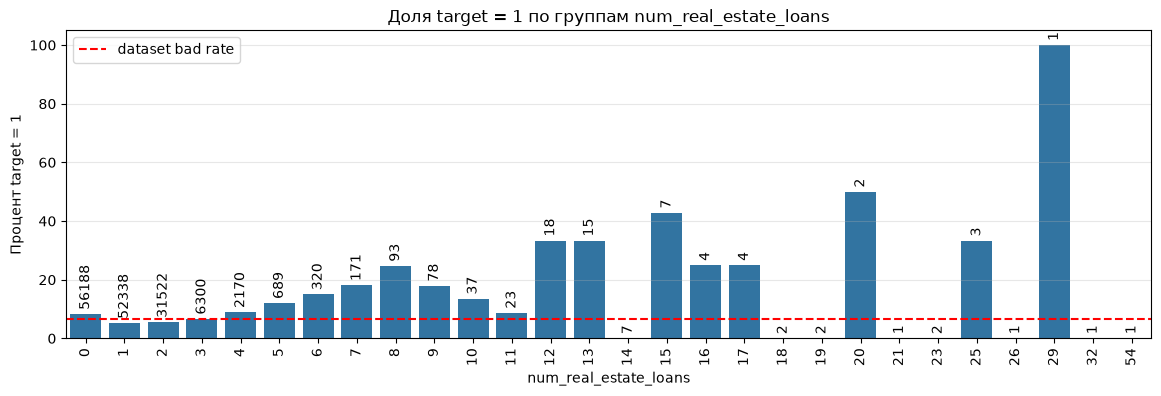

In [2605]:
plot_prebin_bad_rate_count_or_cat_feature(
    data=data,
    feature="num_real_estate_loans"
)

Предварительные сегменты стоит укрупнить. Выполнять это будем опираясь на бизнес-значения самих сегментов и структуру их bad rate.

**Выделим следующие сегменты:**
1. 0;
2. [1, 3];
3. (3, 54].

Такие сегменты сохранят примерный уровень разделения риска по сегментам и будут иметь логичный бизнес-смысл (нет, одна, больше 1).

In [2606]:
segments = [1, 3, 54]

**Построим отчёт по полученным сегментам и итоговый график.**

In [2607]:
num_real_estate_loans_segmented_data, num_real_estate_loans_report = make_segment_report_count_or_cat_feature(
    data=data,
    feature="num_real_estate_loans",
    segments=segments,
    out_path="../data/risk_analysis/num_real_estate_loans/num_real_estate_loans_report.png"
)

In [2608]:
features_reports_names["num_real_estate_loans"] = "num_real_estate_loans_report"

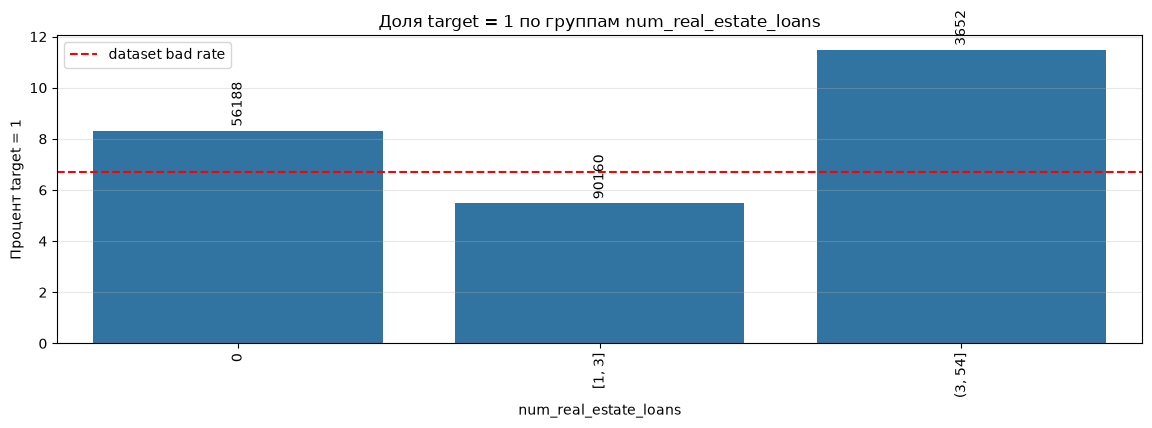

In [2609]:
plot_prebin_bad_rate_count_or_cat_feature(
    data=data,
    feature="num_real_estate_loans",
    segments=segments,
    out_path="../data/risk_analysis/num_real_estate_loans/num_real_estate_loans_graphic.png"
)

In [2610]:
num_real_estate_loans_report

,segment,clients,dataset_share,dataset_bad_rate,bad_count,bad_share,bad_rate,ci_low,ci_high,delta_bad_rate_pp,lift
0,0,56188,0.3746,0.0668,4672,0.4660,0.0831,0.0809,0.0855,1.6309,1.2440
1,"[1, 3]",90160,0.6011,0.0668,4935,0.4922,0.0547,0.0533,0.0562,-1.2104,0.8189
2,"(3, 54]",3652,0.0243,0.0668,419,0.0418,0.1147,0.1048,0.1255,4.7892,1.7165


Большинство сегментов содержит достаточно наблюдений, вследствие чего доверительные интервалы bad rate сравнительно узкие и оценки имеют хорошую статистическую точность.

Последний сегмент не объёмен, поэтому его оценка bad rate сильно теряет в точности.

**Оценим статистическую значимость сегментирования.**

In [2611]:
p_value, cramers_v = stat_power_segments(
    segmented_data=num_real_estate_loans_segmented_data,
    segment_col_name="num_real_estate_loans_segments",
    target_feature="target"
)

In [2612]:
p_value, cramers_v

(np.True_, np.float64(0.06248699427722658))

In [2613]:
features_connects_powers["num_real_estate_loans"] = f"{p_value}; {cramers_v}"

Схема оценивания силы связи.

In [2614]:
cramers_v_scheme

,Cramer's V,Эвристическая интерпретация
0,< 0.1,очень слабая
1,0.1-0.3,слабая
2,0.3-0.5,умеренная
3,> 0.5,сильная


Распределение target статистически различается между сегментами `num_real_estate_loans` ($\chi^{2}$ test, p < 0.001).

Cramer's V $\approx$ 0.06 указывает на слабо выраженную связь между сегментом num_real_estate_loans и target в исследуемой выборке.

**Вывод по признаку:**

У `num_real_estate_loans` наблюдается слабо выраженная нелинейная связь с будущей серьёзной просрочкой. Люди, не имевшие на момент скоринга кридитов, имеют риск несколько выше - в 1.24 раза bad rate выше среднего по датасету, сам сегмент составляет ~37.4% всего датасета и формирует целых ~46.6% всех bad events. В сегменте 1-3 риск незначительно снижается до bad rate ~5.4% против ~6.8% в среднем по датасету, сегмент составляет целых ~60.1% всего датасета и формирует целых ~49.2% всех bad events. В последнем сегменте (3-54) bad rate значительно возрастает, достигая ~11.4%, но сам сегмент составляет всего ~2.4% всего датасета и формирует всего ~4.1%.

In [2615]:
risk_factor_notes.loc[ risk_factor_notes.shape[0] ] = [
    "num_real_estate_loans",
    "1. 0\n2. [1, 3]\n3. (3, 54]",
    "1. (3, 54] || 2.4% || 4.2% || 11.4%",
    "-",
    "Сегмент (3, 54] нельзя принять за маркер, так как он не обладает для этого ни объёмом (2.4% всего датасета), "
    "ни высоким bad rate (11.4%)",
    "Сегмент (3, 54] можно принять за дополнительно условие для сужения других сегментов.",
    p_value,
    cramers_v
]

### `num_dependents`

**Построим график предварительных risk-сегментов.**

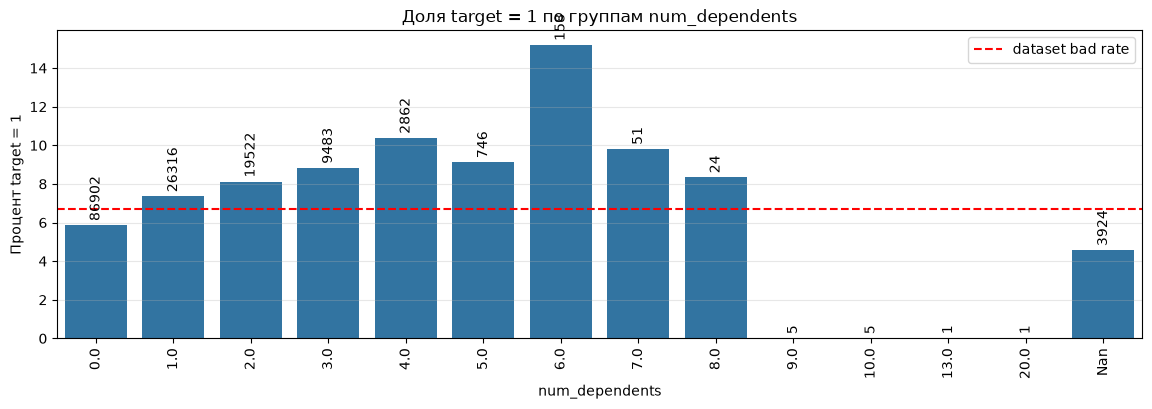

In [2616]:
plot_prebin_bad_rate_count_or_cat_feature(
    data=data,
    feature="num_dependents",
    special_values=[np.nan]
)

Предварительные сегменты стоит укрупнить. Выполнять это будем опираясь на бизнес-значения самих сегментов и структуру их bad rate.

**Выделим следующие сегменты:**
1. 0;
2. [1, 2];
3. (2, np.inf];
4. Nan.

Такие сегменты сохранят примерный уровень разделения риска по сегментам и будут иметь логичный бизнес-смысл (нет, одна, больше 1).

In [2617]:
segments = [1, 2, 20]

**Построим отчёт по полученным сегментам и итоговый график.**

In [2618]:
num_dependents_segmented_data, num_dependents_report = make_segment_report_count_or_cat_feature(
    data=data,
    feature="num_dependents",
    segments=segments,
    special_values=[np.nan],
    out_path="../data/risk_analysis/num_dependents/num_dependents_report.png"
)

In [2619]:
features_reports_names["num_dependents"] = "num_dependents_report"

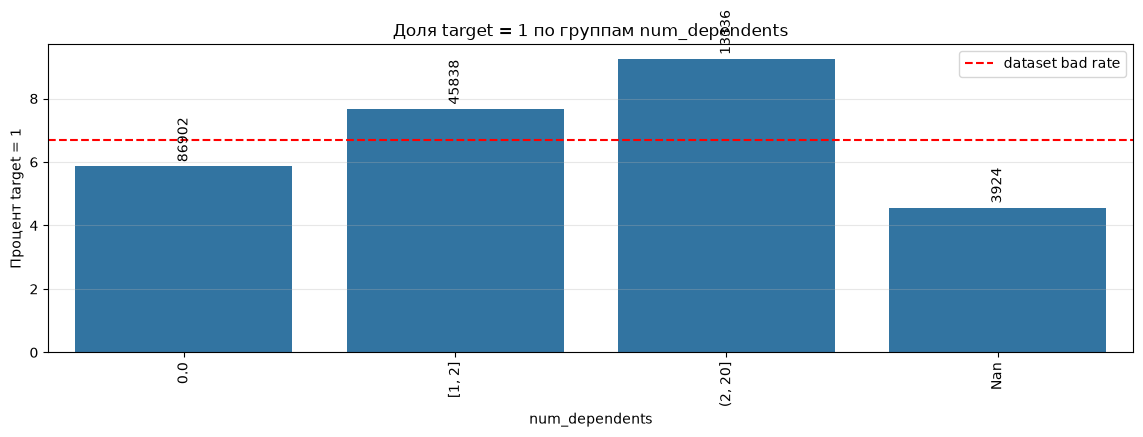

In [2620]:
plot_prebin_bad_rate_count_or_cat_feature(
    data=data,
    feature="num_dependents",
    segments=segments,
    special_values=[np.nan],
    out_path="../data/risk_analysis/num_dependents/num_dependents_graphic.png"
)

In [2621]:
num_dependents_report

,segment,clients,dataset_share,dataset_bad_rate,bad_count,bad_share,bad_rate,ci_low,ci_high,delta_bad_rate_pp,lift
0,0.0,86902,0.5793,0.0668,5095,0.5082,0.0586,0.0571,0.0602,-0.8211,0.8772
1,"[1, 2]",45838,0.3056,0.0668,3519,0.3510,0.0768,0.0744,0.0792,0.9930,1.1486
2,"(2, 20]",13336,0.0889,0.0668,1233,0.1230,0.0925,0.0877,0.0975,2.5617,1.3833
3,Nan,3924,0.0262,0.0668,179,0.0179,0.0456,0.0395,0.0526,-2.1223,0.6825


Большинство сегментов содержит достаточно наблюдений, вследствие чего доверительные интервалы bad rate сравнительно узкие и оценки имеют хорошую статистическую точность.

**Оценим статистическую значимость сегментирования.**

In [2622]:
p_value, cramers_v = stat_power_segments(
    segmented_data=num_dependents_segmented_data,
    segment_col_name="num_dependents_segments",
    target_feature="target"
)

In [2623]:
p_value, cramers_v

(np.True_, np.float64(0.04726117158278401))

In [2624]:
features_connects_powers["num_dependents"] = f"{p_value}; {cramers_v}"

Схема оценивания силы связи.

In [2625]:
cramers_v_scheme

,Cramer's V,Эвристическая интерпретация
0,< 0.1,очень слабая
1,0.1-0.3,слабая
2,0.3-0.5,умеренная
3,> 0.5,сильная


Распределение target статистически различается между сегментами `num_dependents` ($\chi^{2}$ test, p < 0.001).

Cramer's V $\approx$ 0.04 указывает на очень слабую связь между сегментом num_dependents и target в исследуемой выборке.

**Вывод по признаку:**

У `num_dependents` не наблюдается выраженной связи с будущей серьёзной просрочкой. Люди, не имеющие иждевенцев в семье имеют риск несколько ниже - bad rate ~5.8% (57.9% всего датасета и 50.8% всех bad events). Средние сегменты 1-2 и 2-20 имеют несколько повышенный риск, увеличивается в 1.14-1.38 раза по сравнению со средним bad rate, сам сегменты составляют примерно 32% датасета и формируют ~47% всех bad events. Сегмент Nan имеет сниженный риск - в 1.46 раза, но составляет всего ~2.6% всего датасета.

In [2626]:
risk_factor_notes.loc[ risk_factor_notes.shape[0] ] = [
    "num_dependents",
    "1. 0\n2. [1, 2]\n3. (2, 20]\n4. Nan",
    "-",
    "1. Nan || 2.6% || 1.8% || 4.56%",
    "-",
    "-",
    p_value,
    cramers_v
]

### Risk Factor Notes

In [2627]:
risk_factor_notes = (
    risk_factor_notes
    .style
    .set_properties(
        **{
            "text-align": "left",
            "white-space": "pre-wrap"
        }
    )
    .set_table_styles(
        [{
            "selector": "th.col_heading",
            "props": [("text-align", "center")]
        }]
    )
)

## Risk Factor Summary

**Выведем сформированные во время анализа заметки.**

In [2628]:
risk_factor_notes

,feature,segments,high risk segments,low risk segments,summary high risk segments,notes for interaction analysis,Chi^2 test,Cramer's V
0,revolving_utilization,"1. [0.0, 0.2] 2. (0.2, 0.4] 3. (0.4, 0.5] 4. (0.5, 0.7] 5. (0.7, 1.0] 6. (1.0, 2.0] 7. (2.0, 5.0] 8. (5.0, inf]","1. (0.5, 0.7] || 7.5% || 10.8% || 9.5% 2. (0.7, 1.0] || 17.7% || 47.0% || 17.7% 3. (1.0, 2.0] || 2.0% || 11.8% || 40.1% 4. (2.0, 5.0] || 0.08% || 0.3% || 29.0%","1. [0.0, 0.2] || 54.5% || 16.4% || 2.0% 2. (0.2, 0.4] || 13.2% || 8.6% || 4.4%","Сегменты (0.7, 1.0] и (1.0, 2.0] являются очень сильными маркерами риска, они формируют примерно 58% всех bad events, хотя составляют всего порядка 19% датасета.","Сегменты (0.7, 1.0] и (1.0, 2.0] занимают примерно пятую часть датасета и половину bad events. Можно пробовать добавлять условия к этим достаточно объёмным сегментам и пытаться повышать bad rate более узкими условиями.",True,0.302710
1,age,"1. [0.0, 22.0] 2. (22.0, 30.0] 3. (30.0, 45.0] 4. (45.0, 55.0] 5. (55.0, 75.0] 6. (75.0, inf]","1. (22.0, 30.0] || 6.7% || 11.9% || 11.7% 2. (30.0, 45.0] || 27.0% || 37.6% || 9.3%","1. [55.0, 75.0] || 34.6% || 20.1% || 3.8% 2. (75.0, inf] || 6.7% || 2.0% || 2.0%","Сегменты (22.0, 30.0] и (30.0, 45.0] являются не очень сильными маркерами риска, они формируют примерно 49% всех bad events, но составляют при этом примерно 34% датасета.","Сегменты (22.0, 30.0] и (30.0, 45.0] занимают примерно треть датасета и половину bad events. Можно пробовать добавлять условия к этим достаточно объёмным сегментам и пытаться повышать bad rate более узкими условиями.",True,0.113257
2,num_30_59_days_late,"1. 0 2. [1, 2] 3. (2, 13] 4. 96 5. 98","1. [1, 2] || 13.7% || 36.1% || 11.6% 2. (2, 13] || 2.0% || 12.0% || 39.2% 3. 96 || 0% || 0.04% || 80.0% 4. 98 || 0.18% || 1.4% || 54.1%",1. 0 || 84.0% || 50.2% || 4.0%,"Сегменты [1, 2] и (2, 13] являются очень сильными маркерами риска, они формируют примерно 48% всех bad events, хотя составляют при этом всего 16% датасета.","Сегмент [1, 2] занимает примерно 13.% датасета и треть bad events. Можно пробовать добавлять условия к этому сегментаму и пытаться повысить bad rate сузив его дополнительными условиями.",True,0.278413
3,num_60_89_days_late,"1. 0 2. [1, 2] 3. (2, 11] 4. 96 5. 98","1. [1, 2] || 4.6% || 23.3% || 34.1% 2. (2, 11] || 0.3% || 2.8% || 58.6% 3. 96 || 0% || 0.04% || 80.0% 4. 98 || 0.18% || 1.4% || 54.1%",1. 0 || 95.0% || 72.3% || 5.1%,"Сегменты [1, 2] и (2, 11] являются очень сильными маркерами риска, пусть они и составляют примерно 4.6% датасета, но формируют целых 23.3% всех bad events, а также имеют крайне высокий уровень риска (34.1%, 58.6% соответственно).",-,True,0.282281
4,num_90_days_late,"1. 0 2. [1, 2] 3. (2, 17] 4. 96 5. 98","1. [1, 2] || 4.5% || 25.3% || 37.3% 2. (2, 17] || 0.8% || 7.8% || 61.6% 3. 96 || 0% || 0.04% || 80.0% 4. 98 || 0.18% || 1.4% || 54.1%",1. 0 || 94.0% || 65.3% || 4.6%,"Сегменты [1, 2] и (2, 17] являются очень сильными маркерами риска, пусть они и составляют примерно 5.4% датасета, но формируют целых 33% всех bad events, а также имеют крайне высокий уровень риска (37.4%, 61.6% соответственно).",-,True,0.350159
5,debt_ratio,"1. [0.0, 0.1] 2. (0.1, 0.7] 3. (0.7, 1.0] 4. (1.0, 4.0] 5. (4.0, inf]","1. (0.7, 1.0] || 4.9% || 8.1% || 11.1% 2. (1.0, 4.0] || 3.5% || 6.3% || 12.1%",-,"Сегменты (0.7, 1.0] и (1.0, 4.0] не являются сильными маркерами риска, по ним нельзя делать выводы.","Сегменты (0.7, 1.0] и (1.0, 4.0] не являются сильными маркерами, но их можно попробовать в качестве дополнительных условий в interaction analysis.",True,0.061928
6,monthly_income,"1. [0.0, 900.0] 2. (900.0, 3000.0] 3. (3000.0, 4500.0] 4. (4500.0, 6500.0] 5. (6500.0, 13000.0] 6. (13000.0, inf] 7. NaN","1. (900.0, 3000.0] || 13.9% || 20.7% || 10.0% 2. (3000.0, 4500.0] || 15.1% || 19.6% || 8.6%",-,"Сегменты (900.0, 3000.0] и (3000.0, 4500.0] можно принять за слабые маркеры. В совокупности они составляют примерно 30% датасета и формируют 40% всех bad events, но тем не менее bad rate у них не выс

**Сформируем по заданной заметке сформируем итоговую результирующую таблицу.**

In [2629]:
risk_factor_summary = pd.DataFrame({
    "Feature": [
        "Revolving utilization",
        "Age",
        "30-59 DPD",
        "60-89 DPD",
        "90+ DPD",
        "Debt ratio",
        "Income",
        "Open credit lines",
        "Real-estate loans",
        "Dependents"
    ],
    "Cramer's V": [0.303, 0.113, 0.278, 0.282, 0.350, 0.062, 0.073, 0.099, 0.062, 0.047],
    "Main pattern": [
        "Сильная нелинейная градация уровня риска между сегментами." ,
        "Риск в среднем в 1.57% раза выше у молодых людей - (22-45] лет.",
        "Риск быстро возрастает у людей, имеющих просрочки.",
        "Риск быстро возрастает у людей, имеющих просрочки. Сильная градация риска между сегментами.",
        "Риск быстро возрастает у людей, имеющих просрочки. Сильная градация риска между сегментами.",
        "Риск возрастает у людей с высоким Ratio - (0.7-4.0].",
        "У людей с низким-средним доходом ((900-4500]) несколько выше - 1.39 раза в среднем.",
        "Высокий риск у людей, не имевших кредитов на момент скоринга.",
        "Слабая нелинейная связь.",
        "Слабая нелинейная связь."
    ],
    "Main risk segments": [
        "(0.7, 1.0]\n(1.0, 2.0]",
        "(22.0, 30.0]\n(30.0, 45.0]",
        "[1, 2]\n(2, 13]",
        "[1, 2]\n(2, 11]",
        "[1, 2]\n(2, 17]",
        "(0.7, 1.0]\n(1.0, 4.0]",
        "(900.0, 3000.0]\n(3000.0, 4500.0]",
        "0",
        "0",
        "(2, 20]"
    ],
    "Dataset share": [
        "17.75\n1.97", 
        "6.67\n23.03",
        "13.75\n2.05",
        "4.57\n0.32",
        "4.53\n0.85",
        "4.89\n3.50",
        "13.92\n15.17",
        "1.26",
        "37.46",
        "8.89"
    ],
    "Bad share" : [
        "47.05\n11.80",
        "11.92\n37.65",
        "36.19\n12.07",
        "23.32\n2.84",
        "25.34\n7.82",
        "8.17\n6.36",
        "20.73\n19.58",
        "4.83",
        "46.6",
        "12.30"
    ],
    "BR": [
        "17.72\n40.10",
        "11.79\n9.31",
        "17.59\n39.26",
        "34.14\n58.64",
        "37.38\n61.68",
        "11.15\n12.16",
        "9.95\n8.63",
        "25.64",
        "8.31",
        "9.25"
    ],
    "Lift": [
        "2.65\n5.99",
        "1.76\n1.39",
        "2.63\n5.87",
        "5.11\n8.77",
        "5.59\n9.23",
        "1.67\n1.82",
        "1.49\n1.29",
        "3.84",
        "1.24",
        "1.38"
    ],
    "Dataset relevance": [
        "Very\nHigh",
        "Very\nNormal",
        "Very\nHigh",
        "High",
        "High",
        "Very\nNormal",
        "Normal",
        "Low",
        "Normal",
        "Low"
    ],
    "Dataset relevance num": [
        5, 3, 5, 4, 4, 3, 2, 1, 2, 1
    ]
})

risk_factor_summary = (
    risk_factor_summary
    .sort_values(by="Dataset relevance num", ascending=False)
    .drop(columns="Dataset relevance num")
)
risk_factor_summary = (
    risk_factor_summary
    .style
    .set_properties(
        **{
            "text-align": "left",
            "white-space": "pre-wrap"
        }
    )
    .set_table_styles(
        [{
            "selector": "th.col_heading",
            "props": [("text-align", "center")]
        }]
    )
)

In [2630]:
navigation["risk factor summary"] = "risk_factor_summary"

In [2631]:
risk_factor_summary

,Feature,Cramer's V,Main pattern,Main risk segments,Dataset share,Bad share,BR,Lift,Dataset relevance
0,Revolving utilization,0.303000,Сильная нелинейная градация уровня риска между сегментами.,"(0.7, 1.0] (1.0, 2.0]",17.75 1.97,47.05 11.80,17.72 40.10,2.65 5.99,Very High
2,30-59 DPD,0.278000,"Риск быстро возрастает у людей, имеющих просрочки.","[1, 2] (2, 13]",13.75 2.05,36.19 12.07,17.59 39.26,2.63 5.87,Very High
4,90+ DPD,0.350000,"Риск быстро возрастает у людей, имеющих просрочки. Сильная градация риска между сегментами.","[1, 2] (2, 17]",4.53 0.85,25.34 7.82,37.38 61.68,5.59 9.23,High
3,60-89 DPD,0.282000,"Риск быстро возрастает у людей, имеющих просрочки. Сильная градация риска между сегментами.","[1, 2] (2, 11]",4.57 0.32,23.32 2.84,34.14 58.64,5.11 8.77,High
1,Age,0.113000,Риск в среднем в 1.57% раза выше у молодых людей - (22-45] лет.,"(22.0, 30.0] (30.0, 45.0]",6.67 23.03,11.92 37.65,11.79 9.31,1.76 1.39,Very Normal
5,Debt ratio,0.062000,Риск возрастает у людей с высоким Ratio - (0.7-4.0].,"(0.7, 1.0] (1.0, 4.0]",4.89 3.50,8.17 6.36,11.15 12.16,1.67 1.82,Very Normal
6,Income,0.073000,У людей с низким-средним доходом ((900-4500]) несколько выше - 1.39 раза в среднем.,"(900.0, 3000.0] (3000.0, 4500.0]",13.92 15.17,20.73 19.58,9.95 8.63,1.49 1.29,Normal
8,Real-estate loans,0.062000,Слабая нелинейная связь.,0,37.46,46.6,8.31,1.24,Normal
7,Open credit lines,0.099000,"Высокий риск у людей, не имевших кредитов на момент скоринга.",0,1.26,4.83,25.64,3.84,Low
9,Dependents,0.047000,Слабая нелинейная связь.,"(2, 20]",8.89,12.30,9.25,1.38,Low


## Cross-Segment Risk Analysis

### Pairwise Segment Search

Выполним предварительный поиск "интересных" пересечений сегментов. Будем считать пересечение интересным, если:
1. Размер сегмента будет превосходить 0.5% исходного датасета;
2. Будет в себе содержать не менее 1% всех bad events;
3. Его Bad Rate будет выше, чем Bad Rate любого из родителей.

In [2632]:
features_segmented_datas = [
    revolving_utilization_segmented_data,
    age_segmented_data,
    num_30_59_days_late_segmented_data,
    num_60_89_days_late_segmented_data,
    num_90_days_late_segmented_data,
    debt_ratio_segmented_data,
    monthly_income_segmented_data,
    num_open_credit_lines_segmented_data,
    num_real_estate_loans_segmented_data,
    num_dependents_segmented_data
]

features = [
    "revolving_utilization",
    "age",
    "num_30_59_days_late",
    "num_60_89_days_late",
    "num_90_days_late",
    "debt_ratio",
    "monthly_income",
    "num_open_credit_lines",
    "num_real_estate_loans",
    "num_dependents"
]

segments = [
    feature_segmented_data[f"{feature}_segments"].unique().tolist()
    for feature, feature_segmented_data in zip(
        features,
        features_segmented_datas
    )
]

dataset_size = data.shape[0]
dataset_num_bad_events = data["target"].sum()
dataset_bad_rate = data["target"].mean()

In [2633]:
pairwise_report = make_pairwise_segments_analysis(
    features_segmented_datas=features_segmented_datas,
    features=features,
    segments=segments,
    dataset_size=dataset_size,
    dataset_num_bad_events=dataset_num_bad_events,
    dataset_bad_rate=dataset_bad_rate
)

In [2634]:
navigation["pairwise report"] = "pairwise_report"

In [2635]:
pretty_pairwise_report = make_prettier_pairwise_report(
    pairwise_report=pairwise_report,
    dataset_size=dataset_size,
    dataset_share_threshold=0.005,
    dataset_num_bad_events=dataset_num_bad_events,
    bad_share_threshold=0.01)

KeyError: "['Retantion From Smaller Parent'] not in index"

In [ ]:
navigation["pretty pairwise report"] = "pretty_pairwise_report"

In [ ]:
(
    pretty_pairwise_report.sample(10)
    .style
    .set_properties(
        **{
            "text-align": "left",
            "white-space": "pre-wrap"
        }
    )
    .set_table_styles(
        [{
            "selector": "th.col_heading",
            "props": [("text-align", "center")]
        }]
    )
)

,Features,Segments,Size,Overlap Ratio,Retantion From Smaller Parent,Dataset Share,Bad Events,Bad Share,Bad Rate,CI Low,CI High,Delta Bad Rate,Lift,Delta Lift
830,num_60_89_days_late num_real_estate_loans,"[1, 2] 0",3088,True,0.450869,0.020587,1113,0.111011,0.360427,0.343676,0.377525,0.019064,5.392392,0.285215
349,age num_30_59_days_late,"(22.0, 30.0] [1, 2]",1586,True,0.156410,0.010573,387,0.038600,0.244010,0.223507,0.265750,0.068158,3.650660,1.019722
2,revolving_utilization age,"(0.7, 1.0] (45.0, 55.0]",6667,True,0.250385,0.044447,1282,0.127868,0.192290,0.183009,0.201926,0.015139,2.876876,0.226502
319,revolving_utilization num_dependents,"(0.5, 0.7] (2, 20]",1300,True,0.114638,0.008667,134,0.013365,0.103077,0.087701,0.120792,0.007398,1.542144,0.110681
1147,num_real_estate_loans num_dependents,"(3, 54] [1, 2]",1324,True,0.362541,0.008827,161,0.016058,0.121601,0.105083,0.140309,0.006870,1.819288,0.102776
465,age monthly_income,"(30.0, 45.0] (900.0, 3000.0]",5885,True,0.281903,0.039233,739,0.073708,0.125573,0.117351,0.134285,0.026033,1.878718,0.389488
1081,monthly_income num_real_estate_loans,"(900.0, 3000.0] 0",12977,True,0.621623,0.086513,1407,0.140335,0.108423,0.103189,0.113888,0.008882,1.622121,0.132891
545,age num_dependents,"(30.0, 45.0] (2, 20]",6230,True,0.467157,0.041533,681,0.067923,0.109310,0.101801,0.117300,0.016208,1.635395,0.242489
732,num_60_89_days_late num_90_days_late,"[1, 2] [1, 2]",1731,True,0.254634,0.011540,868,0.086575,0.501444,0.477913,0.524969,0.127658,7.502158,1.909902
242,revolving_utilization monthly_income,"(0.4, 0.5] (4500.0, 6500.0]",1427,True,0.199330,0.009513,103,0.010273,0.072179,0.059870,0.086786,0.002300,1.079883,0.034409


### Risk Concentration

Выявим пересечения сегментов имеющих наибольший риск.

In [ ]:
(
    pretty_pairwise_report
    .sort_values(by="Bad Rate", ascending=False)
    .reset_index(drop=True)
    .head(20)
    .style
    .set_properties(
        **{
            "text-align": "left",
            "white-space": "pre-wrap"
        }
    )
    .set_table_styles(
        [{
            "selector": "th.col_heading",
            "props": [("text-align", "center")]
        }]
    )
)

,Features,Segments,Size,Overlap Ratio,Retantion From Smaller Parent,Dataset Share,Bad Events,Bad Share,Bad Rate,CI Low,CI High,Delta Bad Rate,Lift,Delta Lift
0,num_90_days_late num_open_credit_lines,"(2, 17] (2, 58]",938,False,0.738002,0.006253,602,0.060044,0.641791,0.610586,0.671840,0.024954,9.601901,0.373338
1,revolving_utilization num_60_89_days_late,"(1.0, 2.0] [1, 2]",757,True,0.256610,0.005047,429,0.042789,0.566711,0.531162,0.601586,0.165694,8.478616,2.478961
2,num_30_59_days_late num_90_days_late,"(2, 13] [1, 2]",799,True,0.259247,0.005327,439,0.043786,0.549437,0.514783,0.583618,0.156835,8.220179,2.346418
3,num_30_59_days_late num_60_89_days_late,"(2, 13] [1, 2]",987,True,0.320247,0.006580,501,0.049970,0.507599,0.476440,0.538698,0.114997,7.594237,1.720475
4,num_60_89_days_late num_90_days_late,"[1, 2] [1, 2]",1731,True,0.254634,0.011540,868,0.086575,0.501444,0.477913,0.524969,0.127658,7.502158,1.909902
5,revolving_utilization num_30_59_days_late,"(1.0, 2.0] [1, 2]",1218,True,0.412881,0.008120,570,0.056852,0.467980,0.440103,0.496059,0.066963,7.001501,1.001845
6,age num_30_59_days_late,"(30.0, 45.0] (2, 13]",979,True,0.317651,0.006527,435,0.043387,0.444331,0.413483,0.475614,0.051729,6.647680,0.773919
7,revolving_utilization num_30_59_days_late,"(0.7, 1.0] (2, 13]",1309,True,0.424724,0.008727,578,0.057650,0.441558,0.414868,0.468591,0.048956,6.606201,0.732439
8,num_30_59_days_late num_real_estate_loans,"(2, 13] 0",921,False,0.298832,0.006140,397,0.039597,0.431053,0.399422,0.463257,0.038451,6.449031,0.575269
9,revolving_utilization age,"(1.0, 2.0] (30.0, 45.0]",1238,True,0.419661,0.008253,531,0.052962,0.428918,0.401610,0.456665,0.027901,6.417080,0.417425


**Вывод по risk concantration:**
1. 85% топ 20 по BR пересечений используют DPD:
    1. 45% 90+ DPD;
    2. 35% 30-59 DPD;
    3. 20% 60-89 DPD.
    
    Данные признаки имеют стартовый высокий BR, поэтому весьма логично, что сегменты с ними обладают высоким BR;
2. 40% топ 20% по BR пересечений используют Revolving Utilization. Данный признак сам обладает высоким базовым BR, и его дополнительно позволяют повысить признаки:
    1. age;
    2. num_dependents;
    3. num_open_credit_lines.

    Кроме того, данный признак хорошо выступает в коллаборации с другим мощными маркерами: 30-59, 60-89, 90+ DPD.
3. Признаки **num_open_credit_lines**, **age**, **num_real_estate_loans**, **num_dependents**, **num_open_credit_lines**, **monthly_income** выступают как дополнительные маркеры, либо повышающие эффективность мощных маркеров (пп. 1-2), либо выступающие как базовые сегменты для сужения мощными маркерами.

In [ ]:
summary_table = (
    pretty_pairwise_report
    .sort_values(by="Bad Rate", ascending=False)
    .reset_index(drop=True)
    .head(20)
    .iloc[[0, 1, 2, 3, 4, 5, 6, 7, 8, 11, 15, 16, 17, 19], :]
).reset_index(drop=True)

### Dataset Impact

Выявим сегменты, содержащие максимальное количество Bad Events

In [ ]:
(
    pretty_pairwise_report
    .sort_values(by="Bad Events", ascending=False)
    .reset_index(drop=True)
    .head(20)
    .style
    .set_properties(
        **{
            "text-align": "left",
            "white-space": "pre-wrap"
        }
    )
    .set_table_styles(
        [{
            "selector": "th.col_heading",
            "props": [("text-align", "center")]
        }]
    )
)

,Features,Segments,Size,Overlap Ratio,Retantion From Smaller Parent,Dataset Share,Bad Events,Bad Share,Bad Rate,CI Low,CI High,Delta Bad Rate,Lift,Delta Lift
0,revolving_utilization num_real_estate_loans,"(0.7, 1.0] 0",13512,True,0.507455,0.090080,2577,0.257032,0.190719,0.184183,0.197431,0.013568,2.853372,0.202997
1,debt_ratio num_real_estate_loans,"(0.1, 0.7] 0",20575,False,0.366181,0.137167,2249,0.224317,0.109307,0.105117,0.113644,0.026158,1.635359,0.391352
2,num_90_days_late num_open_credit_lines,"[1, 2] (2, 58]",5140,False,0.756105,0.034267,1924,0.191901,0.374319,0.361187,0.387638,0.000533,5.600225,0.007969
3,revolving_utilization age,"(0.7, 1.0] (30.0, 45.0]",9558,True,0.358959,0.063720,1908,0.190305,0.199623,0.191731,0.207757,0.022472,2.986585,0.336211
4,age num_real_estate_loans,"(30.0, 45.0] 0",15037,False,0.370854,0.100247,1839,0.183423,0.122298,0.117158,0.127632,0.029196,1.829718,0.436812
5,revolving_utilization num_30_59_days_late,"(0.7, 1.0] [1, 2]",6184,True,0.299743,0.041227,1705,0.170058,0.275712,0.264716,0.286986,0.098561,4.124948,1.474574
6,num_30_59_days_late num_real_estate_loans,"[1, 2] 0",7437,False,0.360477,0.049580,1653,0.164871,0.222267,0.212962,0.231858,0.046415,3.325360,0.694422
7,revolving_utilization num_dependents,"(0.7, 1.0] [1, 2]",8774,True,0.329515,0.058493,1622,0.161779,0.184864,0.176880,0.193124,0.007713,2.765775,0.115400
8,age num_dependents,"(30.0, 45.0] [1, 2]",15982,True,0.394160,0.106547,1567,0.156294,0.098048,0.093533,0.102755,0.004946,1.466903,0.073997
9,debt_ratio monthly_income,"(4.0, inf] NaN",27427,True,0.922505,0.182847,1546,0.154199,0.056368,0.053700,0.059160,0.000231,0.843325,0.003458


**Вывод по Dataset Impact:**

Перечислю перспективные пересечения признаков:
1. **revolving_utilization (0.7, 1.0]** & **num_real_estate_loans 0** row 0;
2. **num_90_days_late [1, 2]** & **num_open_credit_lines (2, 58]** row 2;
3. **revolving_utilization (0.7, 1.0]** & **age (30.0, 45.0]** row 3;
4. **revolving_utilization (0.7, 1.0]** & **num_30_59_days_late [1, 2]** row 5;
5. **num_30_59_days_late [1, 2]** & **num_real_estate_loans 0** row 6;
6. **revolving_utilization (0.7, 1.0]** & **num_90_days_late [1, 2]** row 10;
7. **age (30.0, 45.0]** & **num_30_59_days_late [1, 2]** row 13;
8. **num_90_days_late [1, 2]** & **debt_ratio (0.1, 0.7]** row 14;
9. **revolving_utilization (0.7, 1.0]** & **num_60_89_days_late [1, 2]** row 18;

Данные комбинации признаков содержат не менее 11% всех bad events. Кроме того, данные сегменты имеют повышенные BR и Delta BR не менее 3%, что в совокупности делает данные сегменты перспективными.

In [ ]:
summary_table = pd.concat(
    [
        summary_table,
        pretty_pairwise_report
        .sort_values(by="Bad Events", ascending=False)
        .reset_index(drop=True)
        .head(20)
        .iloc[[0, 2, 3, 5, 6, 10, 13, 14, 18], :]
    ],
    axis=0
).reset_index(drop=True)

### Incremental Risk Concentration

Выявим комбинации признаков, которые дают наибольший прирост BR.

In [ ]:
(
    pretty_pairwise_report
    .sort_values(by="Delta Bad Rate", ascending=False)
    .reset_index(drop=True)
    .head(20)
    .style
    .set_properties(
        **{
            "text-align": "left",
            "white-space": "pre-wrap"
        }
    )
    .set_table_styles(
        [{
            "selector": "th.col_heading",
            "props": [("text-align", "center")]
        }]
    )
)

,Features,Segments,Size,Overlap Ratio,Retantion From Smaller Parent,Dataset Share,Bad Events,Bad Share,Bad Rate,CI Low,CI High,Delta Bad Rate,Lift,Delta Lift
0,revolving_utilization num_60_89_days_late,"(1.0, 2.0] [1, 2]",757,True,0.256610,0.005047,429,0.042789,0.566711,0.531162,0.601586,0.165694,8.478616,2.478961
1,num_30_59_days_late num_90_days_late,"(2, 13] [1, 2]",799,True,0.259247,0.005327,439,0.043786,0.549437,0.514783,0.583618,0.156835,8.220179,2.346418
2,num_60_89_days_late num_90_days_late,"[1, 2] [1, 2]",1731,True,0.254634,0.011540,868,0.086575,0.501444,0.477913,0.524969,0.127658,7.502158,1.909902
3,num_30_59_days_late num_60_89_days_late,"(2, 13] [1, 2]",987,True,0.320247,0.006580,501,0.049970,0.507599,0.476440,0.538698,0.114997,7.594237,1.720475
4,num_30_59_days_late num_open_credit_lines,"[1, 2] [1, 2]",1369,False,0.123289,0.009127,384,0.038300,0.280497,0.257339,0.304883,0.104645,4.196540,1.565602
5,revolving_utilization num_30_59_days_late,"(0.7, 1.0] [1, 2]",6184,True,0.299743,0.041227,1705,0.170058,0.275712,0.264716,0.286986,0.098561,4.124948,1.474574
6,revolving_utilization num_60_89_days_late,"(0.7, 1.0] [1, 2]",2805,True,0.409549,0.018700,1175,0.117195,0.418895,0.400760,0.437252,0.077531,6.267128,1.159951
7,num_30_59_days_late debt_ratio,"[1, 2] (1.0, 4.0]",888,True,0.169272,0.005920,217,0.021644,0.244369,0.217247,0.273694,0.068517,3.656035,1.025097
8,age num_30_59_days_late,"(22.0, 30.0] [1, 2]",1586,True,0.156410,0.010573,387,0.038600,0.244010,0.223507,0.265750,0.068158,3.650660,1.019722
9,revolving_utilization num_30_59_days_late,"(1.0, 2.0] [1, 2]",1218,True,0.412881,0.008120,570,0.056852,0.467980,0.440103,0.496059,0.066963,7.001501,1.001845


**Вывод по Incremental Risk Concentration:**
1. Комбинации мощных изначальных признаков и их сегментов дают очень большой прирост:
    1. **revolving_utilization** & **DPD**: avg risk delta ~7.86%;
    2. **DPD** & **DPD**: avg risk delta ~13.2%.
2. Комбинации мощных признаков и вспомогательных (самих по себе, не обладающих высоким Bad Rate) дают ощутимый прирост:
    1. **num_open_credit_lines** & **DPD**: avg risk delta ~10.4%;
    2. **debt_ratio** & **DPD** | **num_open_credit_lines** | **revolving_utilization**: avg risk delta ~6%;
    3. **age** & **DPD**: avg risk delta ~6%;
    4. **num_dependents** & **DPD**: avg risk delta ~5.3%.
3. Комбинации изначально слабых признаков (самих по себе, не обладающих высоким Bad Rate) дают ощутимый прирост, но всё равно не обладают высоким bad rate:
    1. **montlhy_income** & **num_dependents**: avg risk delta ~6.2%;
    2. **num_open_credit_lines** & **debt_ratio** | age: avg risk delta ~5.8%;
    3. **num_real_estate_loans** & **num_dependents**: avg risk delta ~5.7%.

In [ ]:
summary_table = pd.concat(
    [
        summary_table,
        pretty_pairwise_report
        .sort_values(by="Delta Bad Rate", ascending=False)
        .reset_index(drop=True)
        .head(20)
        .iloc[[0, 1, 2, 3, 4, 5, 6, 7, 12, 15, 16, 17, 18, 19], :]
    ],
    axis=0
).reset_index(drop=True)

summary_table = summary_table.drop_duplicates()

## Cross-Segment Risk Analysis Summary

Выведем сформированную таблицу сегментов признаков.

In [ ]:
(
    summary_table
    .style
    .set_properties(
        **{
            "text-align": "left",
            "white-space": "pre-wrap"
        }
    )
    .set_table_styles(
        [{
            "selector": "th.col_heading",
            "props": [("text-align", "center")]
        }]
    )
)

,Features,Segments,Size,Overlap Ratio,Retantion From Smaller Parent,Dataset Share,Bad Events,Bad Share,Bad Rate,CI Low,CI High,Delta Bad Rate,Lift,Delta Lift
0,num_90_days_late num_open_credit_lines,"(2, 17] (2, 58]",938,False,0.738002,0.006253,602,0.060044,0.641791,0.610586,0.671840,0.024954,9.601901,0.373338
1,revolving_utilization num_60_89_days_late,"(1.0, 2.0] [1, 2]",757,True,0.256610,0.005047,429,0.042789,0.566711,0.531162,0.601586,0.165694,8.478616,2.478961
2,num_30_59_days_late num_90_days_late,"(2, 13] [1, 2]",799,True,0.259247,0.005327,439,0.043786,0.549437,0.514783,0.583618,0.156835,8.220179,2.346418
3,num_30_59_days_late num_60_89_days_late,"(2, 13] [1, 2]",987,True,0.320247,0.006580,501,0.049970,0.507599,0.476440,0.538698,0.114997,7.594237,1.720475
4,num_60_89_days_late num_90_days_late,"[1, 2] [1, 2]",1731,True,0.254634,0.011540,868,0.086575,0.501444,0.477913,0.524969,0.127658,7.502158,1.909902
5,revolving_utilization num_30_59_days_late,"(1.0, 2.0] [1, 2]",1218,True,0.412881,0.008120,570,0.056852,0.467980,0.440103,0.496059,0.066963,7.001501,1.001845
6,age num_30_59_days_late,"(30.0, 45.0] (2, 13]",979,True,0.317651,0.006527,435,0.043387,0.444331,0.413483,0.475614,0.051729,6.647680,0.773919
7,revolving_utilization num_30_59_days_late,"(0.7, 1.0] (2, 13]",1309,True,0.424724,0.008727,578,0.057650,0.441558,0.414868,0.468591,0.048956,6.606201,0.732439
8,num_30_59_days_late num_real_estate_loans,"(2, 13] 0",921,False,0.298832,0.006140,397,0.039597,0.431053,0.399422,0.463257,0.038451,6.449031,0.575269
9,num_30_59_days_late num_90_days_late,"[1, 2] [1, 2]",2516,True,0.370109,0.016773,1057,0.105426,0.420111,0.400961,0.439505,0.046325,6.285327,0.693071


Выберем среди них наиболее перспективные и обоснуем этот выбор:

In [ ]:
cross_segment_risk_analysis_summary = (
    summary_table
    .iloc[
        [1, 2, 3, 4, 5, 6, 7, 9, 17, 18, 21, 22, 25, 26, 27],
        [0, 1, 2, 5, 7, 8, 11, 12]
    ]
    .reset_index(drop=True)
)

In [ ]:
cross_segment_risk_analysis_summary["Explanations"] = [
    "Очень высокий BR + огромное его повышение",
    "Очень высокий BR + огромное его повышение",
    "Очень высокий BR + огромное его повышение",
    "Очень высокий BR + огромное его повышение + хороший объём",
    "Очень высокий BR + неплохое его повышение",
    "Очень высокий BR + неплохое его повышение",
    "Очень высокий BR + неплохое его повышение",
    "Очень высокий BR + неплохое его повышение + хороший объём",
    "Очень большое повышение BR + очень значительный Bad Share",
    "Высокий Bad Rate + очень значительный Bad Share",
    "Очень высокий BR + очень большое повышение BR + хороший объём",
    "Высокий Bad Rate + огромное его повышение",
    "Высокий Bad Rate + значительное его повышение + хороший объём",
    "Очень высокий BR + значительное его повышение",
    "Высокий Bad Rate + значительное его повышение"
]

In [ ]:
(
    cross_segment_risk_analysis_summary
    .style
    .set_properties(
        **{
            "text-align": "left",
            "white-space": "pre-wrap"
        }
    )
    .set_table_styles(
        [{
            "selector": "th.col_heading",
            "props": [("text-align", "center")]
        }]
    )
)

,Features,Segments,Size,Dataset Share,Bad Share,Bad Rate,Delta Bad Rate,Lift,Explanations
0,revolving_utilization num_60_89_days_late,"(1.0, 2.0] [1, 2]",757,0.005047,0.042789,0.566711,0.165694,8.478616,Очень высокий BR + огромное его повышение
1,num_30_59_days_late num_90_days_late,"(2, 13] [1, 2]",799,0.005327,0.043786,0.549437,0.156835,8.220179,Очень высокий BR + огромное его повышение
2,num_30_59_days_late num_60_89_days_late,"(2, 13] [1, 2]",987,0.006580,0.049970,0.507599,0.114997,7.594237,Очень высокий BR + огромное его повышение
3,num_60_89_days_late num_90_days_late,"[1, 2] [1, 2]",1731,0.011540,0.086575,0.501444,0.127658,7.502158,Очень высокий BR + огромное его повышение + хороший объём
4,revolving_utilization num_30_59_days_late,"(1.0, 2.0] [1, 2]",1218,0.008120,0.056852,0.467980,0.066963,7.001501,Очень высокий BR + неплохое его повышение
5,age num_30_59_days_late,"(30.0, 45.0] (2, 13]",979,0.006527,0.043387,0.444331,0.051729,6.647680,Очень высокий BR + неплохое его повышение
6,revolving_utilization num_30_59_days_late,"(0.7, 1.0] (2, 13]",1309,0.008727,0.057650,0.441558,0.048956,6.606201,Очень высокий BR + неплохое его повышение
7,num_30_59_days_late num_90_days_late,"[1, 2] [1, 2]",2516,0.016773,0.105426,0.420111,0.046325,6.285327,Очень высокий BR + неплохое его повышение + хороший объём
8,revolving_utilization num_30_59_days_late,"(0.7, 1.0] [1, 2]",6184,0.041227,0.170058,0.275712,0.098561,4.124948,Очень большое повышение BR + очень значительный Bad Share
9,num_30_59_days_late num_real_estate_loans,"[1, 2] 0",7437,0.049580,0.164871,0.222267,0.046415,3.325360,Высокий Bad Rate + очень значительный Bad Share


Таким образом, наиболее перспективными оказались комбинации:
1. Сильных признаков с сильными признаками (**revolving_utilization**, **DPD**, **num_real_estate_loans**);
2. Сильных признаков с слабыми признаками (**revolving_utilization**, **DPD** & **age**, **debt_ratio**, **monthly_income**, **num_open_credit_lines**).